In [2]:
# Import Libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate,
    cross_val_predict
)

from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.dummy import DummyClassifier

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree,
    export_text
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import joblib

RANDOM_STATE = 42

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [27]:
# Load Breast Cancer Dataset

# Load Dataset - 1

raw = load_breast_cancer(as_frame=True)

X = raw.data.copy()

# Make Malignant = 1

y = (raw.target == 0).astype(int)

y.name = "Malignant"

print("Dataset Loaded Successfully\n")

print("Feature Matrix Shape :", X.shape)

print("Target Shape :", y.shape)

print("\nPositive Class")

print("1 = Malignant")
print("0 = Benign")

Dataset Loaded Successfully

Feature Matrix Shape : (569, 30)
Target Shape : (569,)

Positive Class
1 = Malignant
0 = Benign


In [6]:
# Data Audit

print("Shape of Dataset")

display(X.shape)

print("\nData Types")

display(X.dtypes)

print("\nMissing Values")

display(X.isnull().sum())

print("\nDuplicate Rows")

print(X.duplicated().sum())

print("\nUnique Values")

display(X.nunique())

print("\nStatistical Summary")

display(X.describe())


# Leakage Check

print("Checking for Target Leakage")

assert "target" not in X.columns
assert "Malignant" not in X.columns

print("No Target Leakage Found")

Shape of Dataset


(569, 30)


Data Types


mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      


Missing Values


mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


Duplicate Rows
0

Unique Values


mean radius                456
mean texture               479
mean perimeter             522
mean area                  539
mean smoothness            474
mean compactness           537
mean concavity             537
mean concave points        542
mean symmetry              432
mean fractal dimension     499
radius error               540
texture error              519
perimeter error            533
area error                 528
smoothness error           547
compactness error          541
concavity error            533
concave points error       507
symmetry error             498
fractal dimension error    545
worst radius               457
worst texture              511
worst perimeter            514
worst area                 544
worst smoothness           411
worst compactness          529
worst concavity            539
worst concave points       492
worst symmetry             500
worst fractal dimension    535
dtype: int64


Statistical Summary


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Checking for Target Leakage
No Target Leakage Found


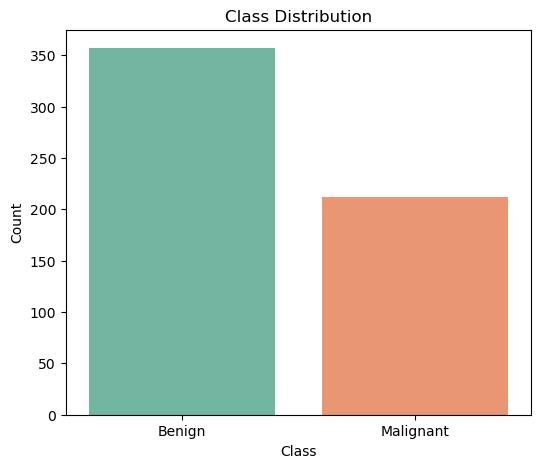

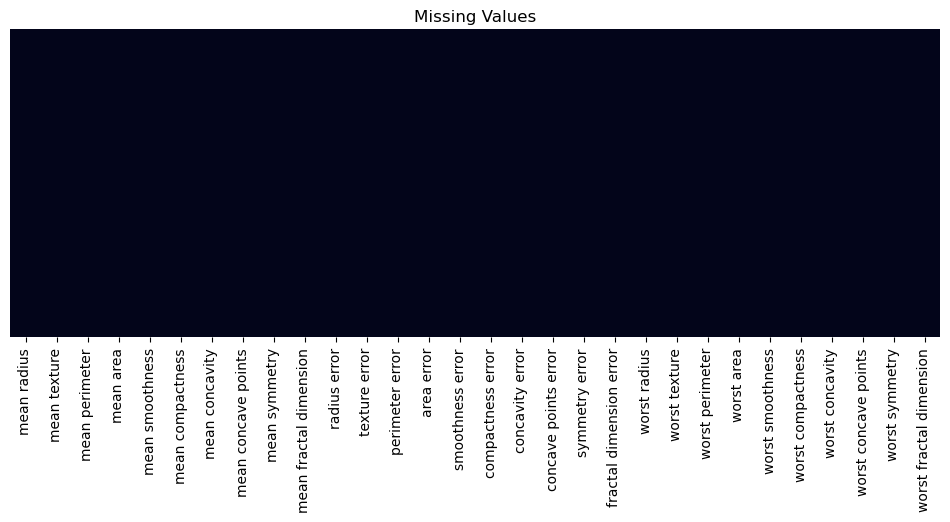

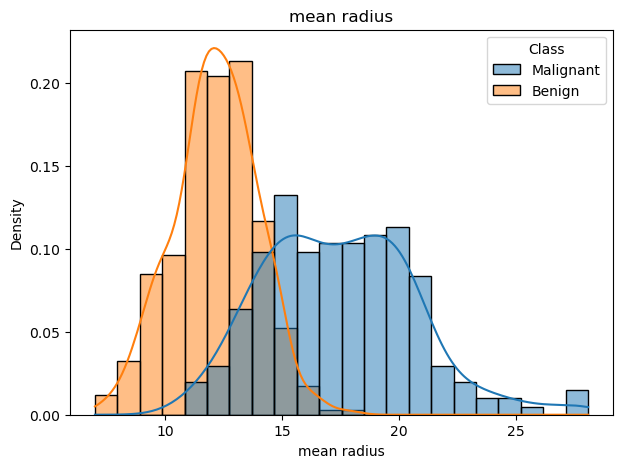

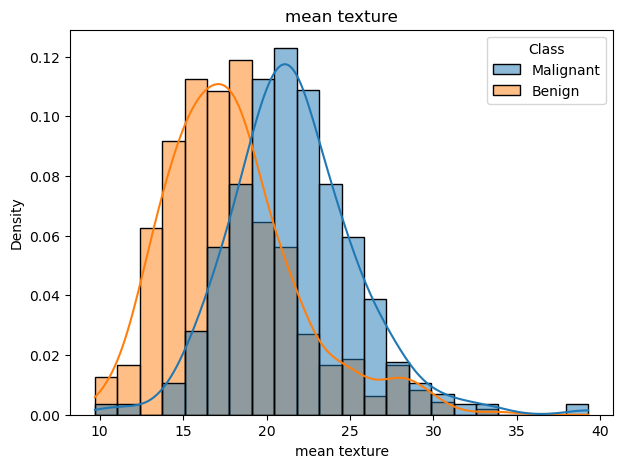

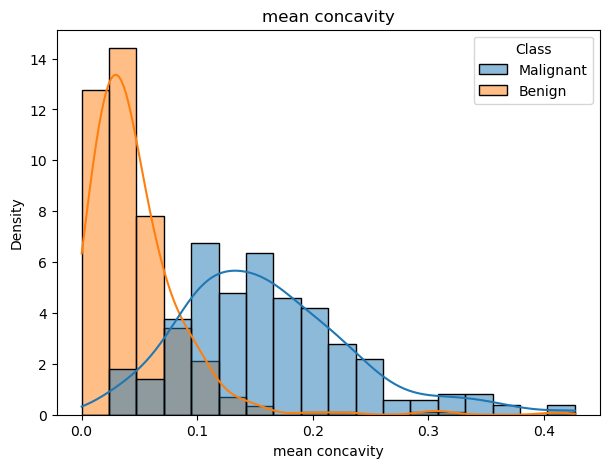

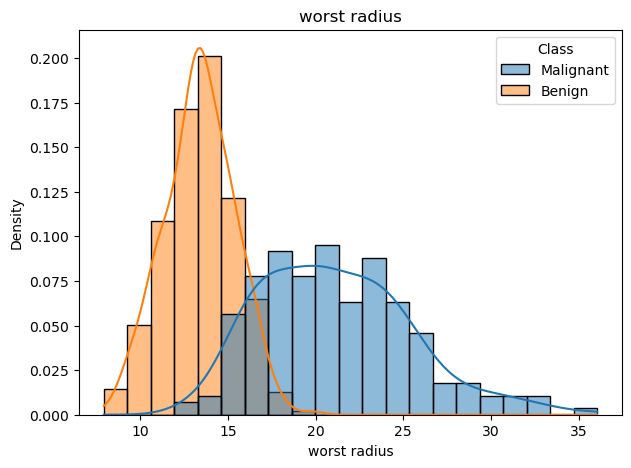

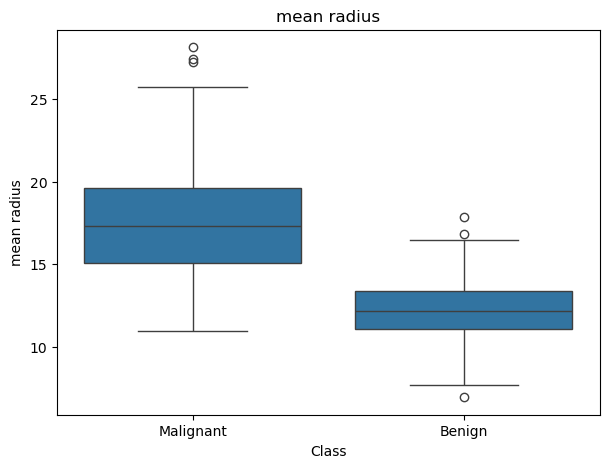

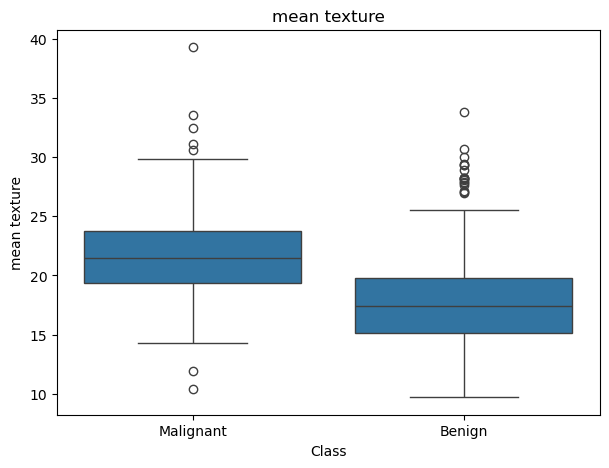

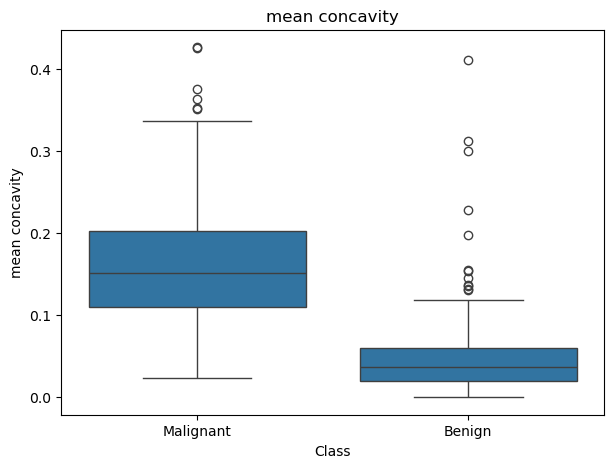

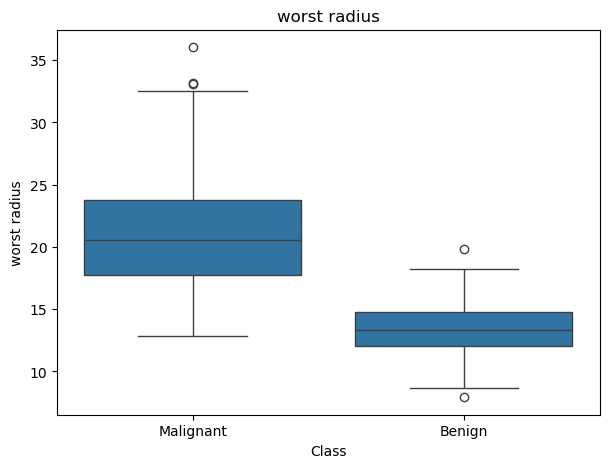

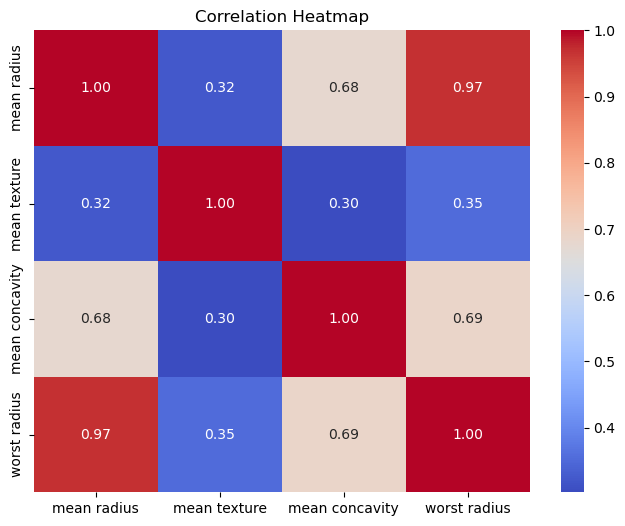

In [8]:
# Exploratory Data Analysis (EDA)

# 1 Class Distribution

plt.figure(figsize=(6,5))

sns.countplot(
    x=y,
    palette="Set2"
)

plt.xticks(
    [0,1],
    ["Benign","Malignant"]
)

plt.title("Class Distribution")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

# 2 Missing Value Heatmap

plt.figure(figsize=(12,4))

sns.heatmap(
    X.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values")

plt.show()

# 3 Selected Feature Distribution

selected_features = [
    "mean radius",
    "mean texture",
    "mean concavity",
    "worst radius"
]

eda = X[selected_features].copy()

eda["Class"] = y

eda["Class"] = eda["Class"].map({
    0:"Benign",
    1:"Malignant"
})

for feature in selected_features:

    plt.figure(figsize=(7,5))

    sns.histplot(
        data=eda,
        x=feature,
        hue="Class",
        kde=True,
        stat="density",
        common_norm=False
    )

    plt.title(feature)

    plt.show()


# 4 Boxplots

for feature in selected_features:

    plt.figure(figsize=(7,5))

    sns.boxplot(
        x="Class",
        y=feature,
        data=eda
    )

    plt.title(feature)

    plt.show()

# 5 Correlation Heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    X[selected_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()


# EDA Observations

# 1. The dataset contains 569 observations and 30 numerical features.

# 2. There are no missing values.

# 3. The malignant class is smaller than the benign class, making stratified sampling appropriate.

# 4. Features such as mean radius, worst radius, and mean concavity show good separation between malignant and benign cases.

# 5. Some numerical predictors are strongly correlated, which is acceptable for tree-based models but should be noted.

In [9]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

print("\nTraining Class Distribution")

print(y_train.value_counts())

print("\nTesting Class Distribution")

print(y_test.value_counts())

Training Shape : (455, 30)
Testing Shape  : (114, 30)

Training Class Distribution
Malignant
0    285
1    170
Name: count, dtype: int64

Testing Class Distribution
Malignant
0    72
1    42
Name: count, dtype: int64


In [10]:
# Dummy Baseline

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

dummy = DummyClassifier(strategy="prior")

dummy_cv = cross_validate(
    dummy,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

dummy_results = pd.DataFrame(dummy_cv).filter(regex="test_")

summary = pd.DataFrame({
    "Mean": dummy_results.mean(),
    "Std": dummy_results.std()
})

display(summary)

,Mean,Std
test_accuracy,0.626374,0.0
test_balanced_accuracy,0.500000,0.0
test_precision,0.000000,0.0
test_recall,0.000000,0.0
test_f1,0.000000,0.0
test_roc_auc,0.500000,0.0
test_pr_auc,0.373626,0.0


In [11]:
# Basic CART (Default Decision Tree)

# Basic CART Model

basic_cart = DecisionTreeClassifier(
    criterion="gini",
    random_state=RANDOM_STATE
)

basic_cv = cross_validate(
    basic_cart,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

basic_results = pd.DataFrame(basic_cv)

summary_basic = pd.DataFrame({
    "Train Mean": basic_results.filter(regex="train").mean(),
    "Test Mean": basic_results.filter(regex="test").mean(),
    "Train Std": basic_results.filter(regex="train").std(),
    "Test Std": basic_results.filter(regex="test").std()
})

display(summary_basic)

# Fit Basic CART

basic_cart.fit(X_train, y_train)

print("Tree Depth :", basic_cart.get_depth())
print("Number of Leaves :", basic_cart.get_n_leaves())
print("Number of Nodes :", basic_cart.tree_.node_count)

,Train Mean,Test Mean,Train Std,Test Std
test_accuracy,NaN,0.923077,NaN,0.036446
test_balanced_accuracy,NaN,0.917234,NaN,0.041973
test_f1,NaN,0.896184,NaN,0.049984
test_pr_auc,NaN,0.845327,NaN,0.067780
test_precision,NaN,0.899593,NaN,0.045372
test_recall,NaN,0.894118,NaN,0.067711
test_roc_auc,NaN,0.917234,NaN,0.041973
train_accuracy,1.0,NaN,0.0,NaN
train_balanced_accuracy,1.0,NaN,0.0,NaN
train_f1,1.0,NaN,0.0,NaN


Tree Depth : 8
Number of Leaves : 24
Number of Nodes : 47


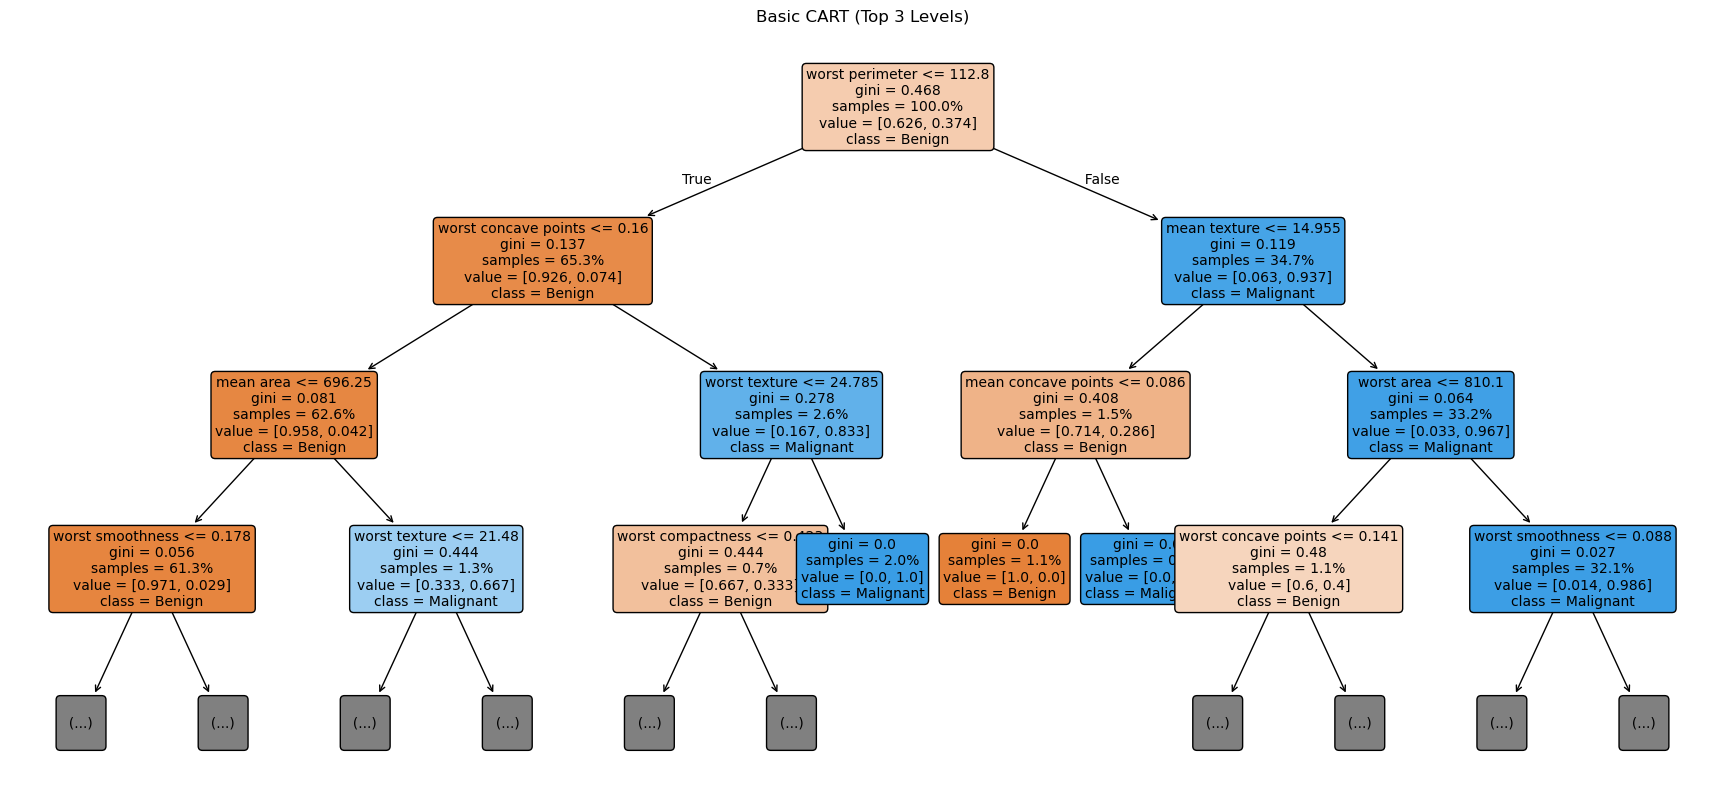

|--- worst perimeter <= 112.80
|   |--- worst concave points <= 0.16
|   |   |--- mean area <= 696.25
|   |   |   |--- worst smoothness <= 0.18
|   |   |   |   |--- worst perimeter <= 102.40
|   |   |   |   |   |--- area error <= 47.03
|   |   |   |   |   |   |--- worst texture <= 33.35
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- worst texture >  33.35
|   |   |   |   |   |   |   |--- mean texture <= 23.20
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |--- mean texture >  23.20
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- area error >  47.03
|   |   |   |   |   |   |--- concavity error <= 0.02
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- concavity error >  0.02
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- worst perimeter >  102.40
|   |   |   |   |   |--- worst smoothness <= 0.14
|   |   |   |   |   |   |--- worst perimeter <= 102.70
|   |   |   |   |   |   |   |

In [13]:
# Tree Visualization

plt.figure(figsize=(22,10))

plot_tree(
    basic_cart,
    feature_names=X.columns,
    class_names=["Benign","Malignant"],
    filled=True,
    rounded=True,
    proportion=True,
    max_depth=3,
    fontsize=10
)

plt.title("Basic CART (Top 3 Levels)")

plt.show()

# Display Decision Rules

rules = export_text(
    basic_cart,
    feature_names=list(X.columns)
)

print(rules[:5000])

In [14]:
# Hyperparameter Tuning

# Create Pipeline

tree_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

# Parameter Grid

param_grid = {

    "model__criterion":[
        "gini",
        "entropy",
        "log_loss"
    ],

    "model__max_depth":[
        2,3,4,5,6,8,None
    ],

    "model__min_samples_split":[
        2,5,10,20
    ],

    "model__min_samples_leaf":[
        1,2,5,10,20
    ],

    "model__class_weight":[
        None,
        "balanced"
    ]
}

# Grid Search

grid = GridSearchCV(

    estimator=tree_pipe,

    param_grid=param_grid,

    scoring=scoring,

    refit="roc_auc",

    cv=cv,

    n_jobs=-1,

    return_train_score=True
)

grid.fit(X_train,y_train)

print("Best Parameters\n")

print(grid.best_params_)

print("\nBest ROC AUC")

print(grid.best_score_)

Best Parameters

{'model__class_weight': 'balanced', 'model__criterion': 'gini', 'model__max_depth': 4, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}

Best ROC AUC
0.9753869969040248


In [15]:
# Cost Complexity Pruning

# Find Alpha Values

base_tree = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

path = base_tree.cost_complexity_pruning_path(
    X_train,
    y_train
)

ccp_alphas = np.unique(path.ccp_alphas[:-1])

print("Number of Alpha Values :",len(ccp_alphas))

# Grid Search for Best Alpha

alpha_grid = {

    "model__ccp_alpha":ccp_alphas,

    "model__class_weight":[
        None,
        "balanced"
    ]
}

prune_search = GridSearchCV(

    tree_pipe,

    alpha_grid,

    scoring=scoring,

    refit="roc_auc",

    cv=cv,

    n_jobs=-1,

    return_train_score=True
)

prune_search.fit(
    X_train,
    y_train
)

print("Best Alpha")

print(prune_search.best_params_)

print("\nBest ROC AUC")

print(prune_search.best_score_)

# Best Tuned Model

best_tree = prune_search.best_estimator_

best_tree.fit(
    X_train,
    y_train
)

Number of Alpha Values : 16
Best Alpha
{'model__ccp_alpha': np.float64(0.010508985449562663), 'model__class_weight': 'balanced'}

Best ROC AUC
0.9477296181630546


,steps,"[('imputer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,criterion,'gini'


,Train Mean,Test Mean,Train Std,Test Std
test_accuracy,NaN,0.942857,NaN,0.026236
test_balanced_accuracy,NaN,0.937771,NaN,0.032969
test_f1,NaN,0.922335,NaN,0.038036
test_pr_auc,NaN,0.898852,NaN,0.052609
test_precision,NaN,0.931040,NaN,0.043104
test_recall,NaN,0.917647,NaN,0.070220
test_roc_auc,NaN,0.947730,NaN,0.034800
train_accuracy,0.966484,NaN,0.005630,NaN
train_balanced_accuracy,0.965235,NaN,0.006352,NaN
train_f1,0.955372,NaN,0.007532,NaN


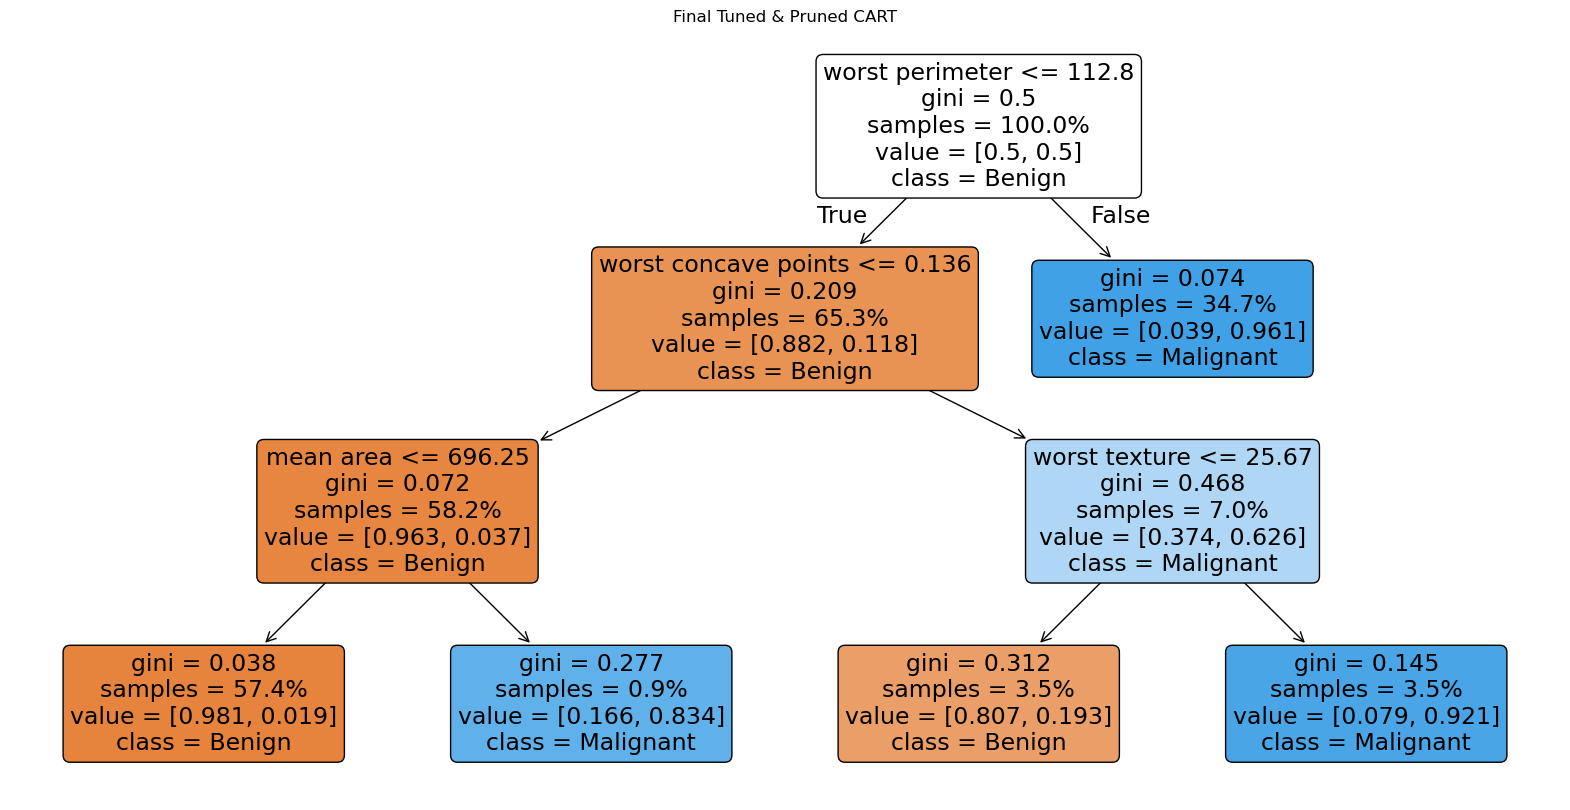

In [16]:
# Tuned & Pruned CART

pruned_cv = cross_validate(

    best_tree,

    X_train,

    y_train,

    cv=cv,

    scoring=scoring,

    return_train_score=True
)

pruned_results = pd.DataFrame(pruned_cv)

summary_pruned = pd.DataFrame({

    "Train Mean":pruned_results.filter(regex="train").mean(),

    "Test Mean":pruned_results.filter(regex="test").mean(),

    "Train Std":pruned_results.filter(regex="train").std(),

    "Test Std":pruned_results.filter(regex="test").std()

})

display(summary_pruned)

# Visualize Final Pruned Tree

fitted_tree = best_tree.named_steps["model"]

plt.figure(figsize=(20,10))

plot_tree(
    fitted_tree,
    feature_names=X.columns,
    class_names=["Benign","Malignant"],
    filled=True,
    rounded=True,
    proportion=True
)

plt.title("Final Tuned & Pruned CART")

plt.show()

In [17]:
# Random Forest

rf = RandomForestClassifier(

    n_estimators=500,

    max_features="sqrt",

    class_weight="balanced",

    random_state=RANDOM_STATE,

    n_jobs=-1
)

rf_cv = cross_validate(

    rf,

    X_train,

    y_train,

    cv=cv,

    scoring=scoring,

    return_train_score=True
)

rf_results = pd.DataFrame(rf_cv)

summary_rf = pd.DataFrame({

    "Train Mean":rf_results.filter(regex="train").mean(),

    "Test Mean":rf_results.filter(regex="test").mean(),

    "Train Std":rf_results.filter(regex="train").std(),

    "Test Std":rf_results.filter(regex="test").std()

})

display(summary_rf)

,Train Mean,Test Mean,Train Std,Test Std
test_accuracy,NaN,0.960440,NaN,0.012529
test_balanced_accuracy,NaN,0.955366,NaN,0.012693
test_f1,NaN,0.946509,NaN,0.016577
test_pr_auc,NaN,0.987680,NaN,0.006849
test_precision,NaN,0.958929,NaN,0.032137
test_recall,NaN,0.935294,NaN,0.024608
test_roc_auc,NaN,0.988958,NaN,0.007332
train_accuracy,1.0,NaN,0.000000e+00,NaN
train_balanced_accuracy,1.0,NaN,0.000000e+00,NaN
train_f1,1.0,NaN,0.000000e+00,NaN


,Model,Accuracy,Balanced Accuracy,Sensitivity,Precision,F1 Score,ROC AUC,PR AUC
3,Random Forest,0.960440,0.955366,0.935294,0.958929,0.946509,0.988958,0.987680
2,Tuned & Pruned CART,0.942857,0.937771,0.917647,0.931040,0.922335,0.947730,0.898852
1,Basic CART,0.923077,0.917234,0.894118,0.899593,0.896184,0.917234,0.845327
0,Dummy,0.626374,0.500000,0.000000,0.000000,0.000000,0.500000,0.373626


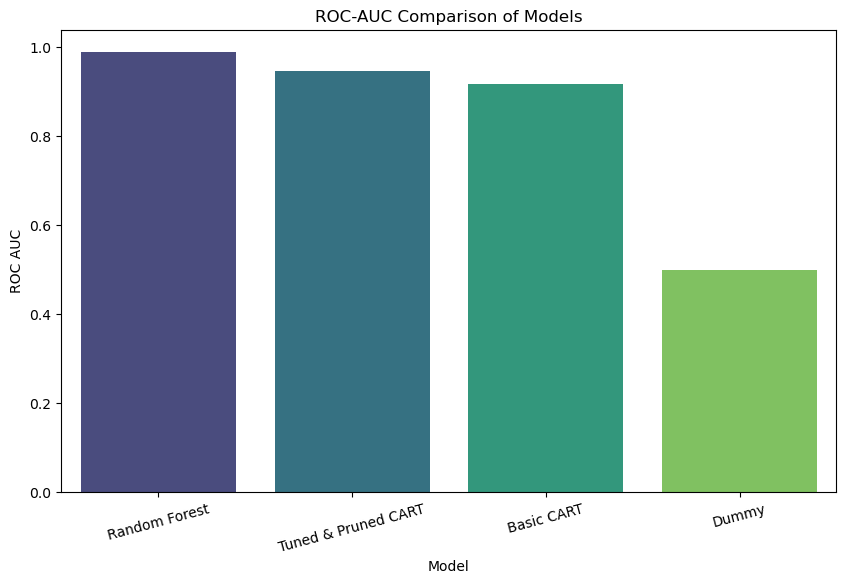

In [18]:
# Model Comparison

# Compare All Models

comparison = pd.DataFrame({

    "Model":[
        "Dummy",
        "Basic CART",
        "Tuned & Pruned CART",
        "Random Forest"
    ],

    "Accuracy":[
        dummy_results["test_accuracy"].mean(),
        basic_results["test_accuracy"].mean(),
        pruned_results["test_accuracy"].mean(),
        rf_results["test_accuracy"].mean()
    ],

    "Balanced Accuracy":[
        dummy_results["test_balanced_accuracy"].mean(),
        basic_results["test_balanced_accuracy"].mean(),
        pruned_results["test_balanced_accuracy"].mean(),
        rf_results["test_balanced_accuracy"].mean()
    ],

    "Sensitivity":[
        dummy_results["test_recall"].mean(),
        basic_results["test_recall"].mean(),
        pruned_results["test_recall"].mean(),
        rf_results["test_recall"].mean()
    ],

    "Precision":[
        dummy_results["test_precision"].mean(),
        basic_results["test_precision"].mean(),
        pruned_results["test_precision"].mean(),
        rf_results["test_precision"].mean()
    ],

    "F1 Score":[
        dummy_results["test_f1"].mean(),
        basic_results["test_f1"].mean(),
        pruned_results["test_f1"].mean(),
        rf_results["test_f1"].mean()
    ],

    "ROC AUC":[
        dummy_results["test_roc_auc"].mean(),
        basic_results["test_roc_auc"].mean(),
        pruned_results["test_roc_auc"].mean(),
        rf_results["test_roc_auc"].mean()
    ],

    "PR AUC":[
        dummy_results["test_pr_auc"].mean(),
        basic_results["test_pr_auc"].mean(),
        pruned_results["test_pr_auc"].mean(),
        rf_results["test_pr_auc"].mean()
    ]

})

comparison = comparison.sort_values(
    by="ROC AUC",
    ascending=False
)

display(comparison)

# Visual Comparison

plt.figure(figsize=(10,6))

sns.barplot(
    data=comparison,
    x="Model",
    y="ROC AUC",
    palette="viridis"
)

plt.title("ROC-AUC Comparison of Models")

plt.xticks(rotation=15)

plt.show()

,Threshold,Sensitivity,Specificity
0,0.050,0.970588,0.740351
1,0.055,0.935294,0.933333
2,0.060,0.935294,0.933333
3,0.065,0.935294,0.933333
4,0.070,0.935294,0.933333


Selected Threshold = 0.8499999999999999


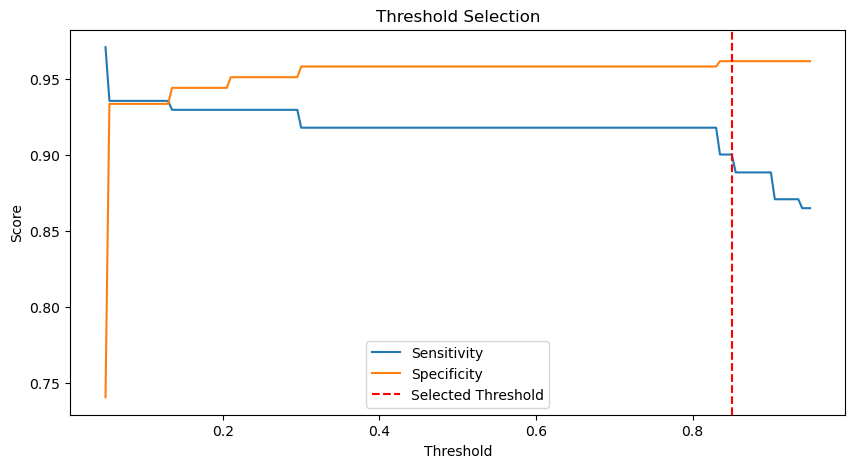

In [19]:
# Threshold Experiment

# Generate Out-of-Fold Probabilities

selected_model = prune_search.best_estimator_

oof_prob = cross_val_predict(
    selected_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:,1]

# Find Best Threshold

threshold_results = []

for threshold in np.linspace(0.05,0.95,181):

    prediction = (oof_prob >= threshold).astype(int)

    tn,fp,fn,tp = confusion_matrix(
        y_train,
        prediction
    ).ravel()

    sensitivity = tp/(tp+fn) if(tp+fn)!=0 else 0

    specificity = tn/(tn+fp) if(tn+fp)!=0 else 0

    threshold_results.append([
        threshold,
        sensitivity,
        specificity
    ])

threshold_df = pd.DataFrame(
    threshold_results,
    columns=[
        "Threshold",
        "Sensitivity",
        "Specificity"
    ]
)

display(threshold_df.head())

# Select Threshold

TARGET_SENSITIVITY = 0.90

candidate = threshold_df[
    threshold_df["Sensitivity"]>=TARGET_SENSITIVITY
]

selected_threshold = candidate.sort_values(
    by="Specificity",
    ascending=False
).iloc[0]["Threshold"]

print("Selected Threshold =",selected_threshold)

# Threshold Plot

plt.figure(figsize=(10,5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Sensitivity"],
    label="Sensitivity"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Specificity"],
    label="Specificity"
)

plt.axvline(
    selected_threshold,
    color="red",
    linestyle="--",
    label="Selected Threshold"
)

plt.legend()

plt.xlabel("Threshold")

plt.ylabel("Score")

plt.title("Threshold Selection")

plt.show()

In [20]:
# Final Test Evaluation

# Fit Final Model

final_model = selected_model.fit(
    X_train,
    y_train
)

test_prob = final_model.predict_proba(
    X_test
)[:,1]

# Evaluation Function

def evaluate_model(
    y_true,
    probability,
    threshold
):

    prediction = (
        probability >= threshold
    ).astype(int)

    tn,fp,fn,tp = confusion_matrix(
        y_true,
        prediction
    ).ravel()

    specificity = tn/(tn+fp)

    results = {

        "TN":tn,

        "FP":fp,

        "FN":fn,

        "TP":tp,

        "Accuracy":
        accuracy_score(
            y_true,
            prediction
        ),

        "Balanced Accuracy":
        balanced_accuracy_score(
            y_true,
            prediction
        ),

        "Sensitivity":
        recall_score(
            y_true,
            prediction
        ),

        "Specificity":
        specificity,

        "Precision":
        precision_score(
            y_true,
            prediction
        ),

        "F1":
        f1_score(
            y_true,
            prediction
        ),

        "ROC AUC":
        roc_auc_score(
            y_true,
            probability
        ),

        "PR AUC":
        average_precision_score(
            y_true,
            probability
        )

    }

    return pd.Series(results)

# Final Metrics

final_results = evaluate_model(
    y_test,
    test_prob,
    selected_threshold
)

display(final_results)

TN                   69.000000
FP                    3.000000
FN                    5.000000
TP                   37.000000
Accuracy              0.929825
Balanced Accuracy     0.919643
Sensitivity           0.880952
Specificity           0.958333
Precision             0.925000
F1                    0.902439
ROC AUC               0.943122
PR AUC                0.892333
dtype: float64

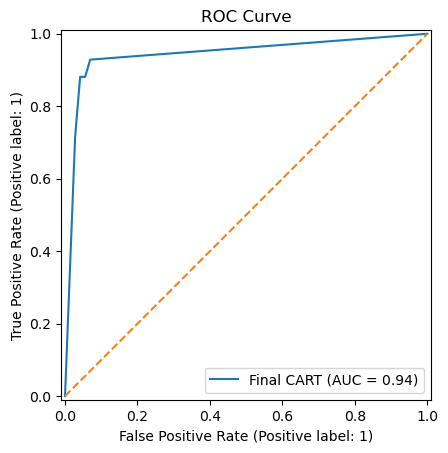

In [21]:
# ROC Curve

RocCurveDisplay.from_predictions(
    y_test,
    test_prob,
    name="Final CART"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.title("ROC Curve")

plt.show()

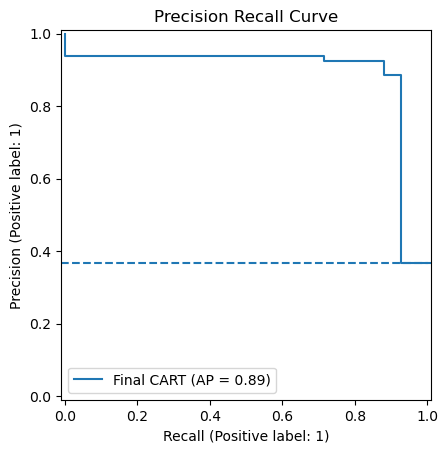

In [22]:
# Precision Recall Curve

PrecisionRecallDisplay.from_predictions(
    y_test,
    test_prob,
    name="Final CART"
)

plt.axhline(
    y_test.mean(),
    linestyle="--"
)

plt.title("Precision Recall Curve")

plt.show()

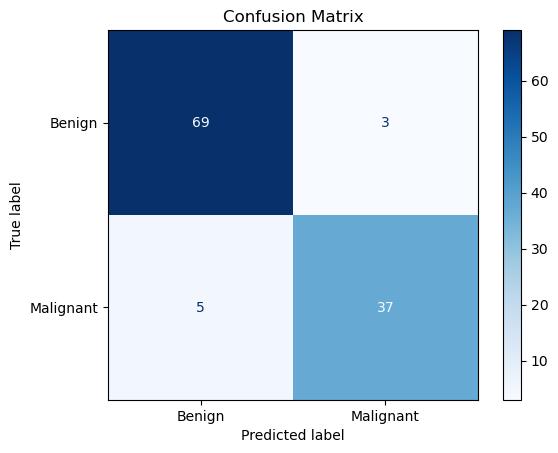

In [23]:
# Confusion Matrix

test_prediction = (
    test_prob >= selected_threshold
).astype(int)

ConfusionMatrixDisplay.from_predictions(

    y_test,

    test_prediction,

    display_labels=[
        "Benign",
        "Malignant"
    ],

    cmap="Blues",

    values_format="d"

)

plt.title("Confusion Matrix")

plt.show()

worst perimeter            0.818839
worst concave points       0.104559
worst texture              0.044659
mean area                  0.031944
mean radius                0.000000
concavity error            0.000000
worst symmetry             0.000000
worst concavity            0.000000
worst compactness          0.000000
worst smoothness           0.000000
worst area                 0.000000
worst radius               0.000000
fractal dimension error    0.000000
symmetry error             0.000000
concave points error       0.000000
dtype: float64

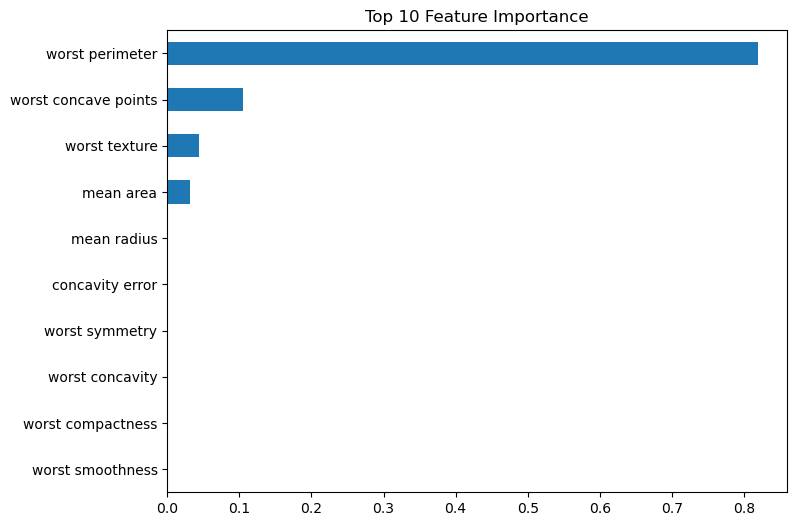

,Feature,Importance,Std
22,worst perimeter,0.210621,0.036476
27,worst concave points,0.095332,0.024059
3,mean area,0.008488,0.012144
21,worst texture,0.001731,0.000984
0,mean radius,0.000000,0.000000
16,concavity error,0.000000,0.000000
28,worst symmetry,0.000000,0.000000
26,worst concavity,0.000000,0.000000
25,worst compactness,0.000000,0.000000
24,worst smoothness,0.000000,0.000000


In [24]:
# Feature Importance

# Impurity Importance

fitted_tree = final_model.named_steps["model"]

importance = pd.Series(

    fitted_tree.feature_importances_,

    index=X.columns

).sort_values(
    ascending=False
)

display(
    importance.head(15)
)

# Plot Feature Importance

plt.figure(figsize=(8,6))

importance.head(10).plot(
    kind="barh"
)

plt.title("Top 10 Feature Importance")

plt.gca().invert_yaxis()

plt.show()

# Permutation Importance

perm = permutation_importance(

    final_model,

    X_test,

    y_test,

    scoring="roc_auc",

    n_repeats=30,

    random_state=RANDOM_STATE
)

perm_df = pd.DataFrame({

    "Feature":X.columns,

    "Importance":perm.importances_mean,

    "Std":perm.importances_std

}).sort_values(
    by="Importance",
    ascending=False
)

display(
    perm_df.head(15)
)

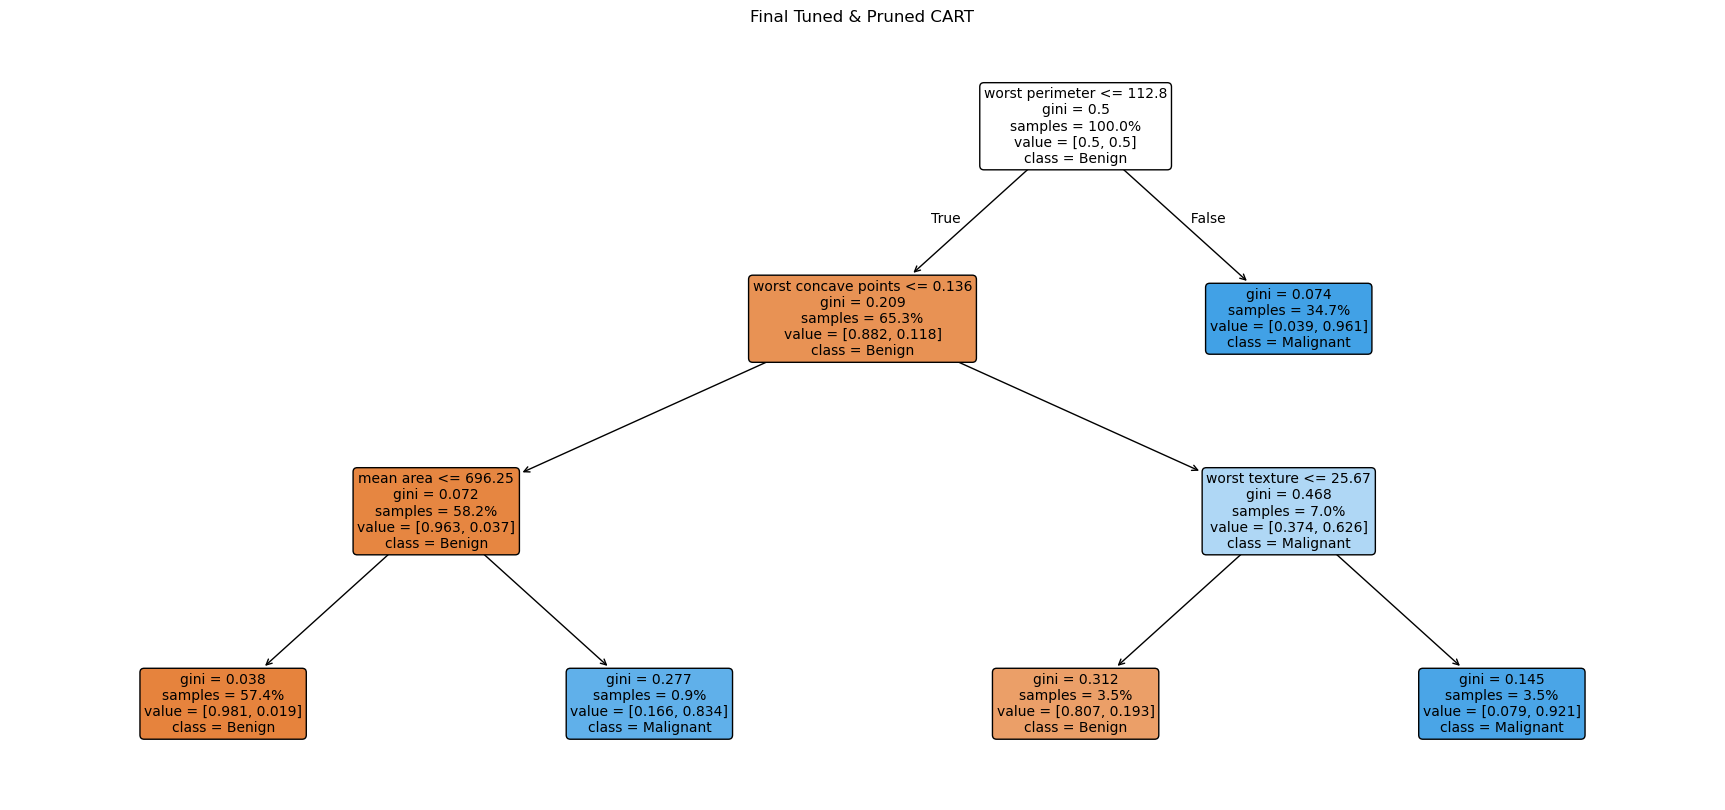

|--- worst perimeter <= 112.80
|   |--- worst concave points <= 0.14
|   |   |--- mean area <= 696.25
|   |   |   |--- class: 0
|   |   |--- mean area >  696.25
|   |   |   |--- class: 1
|   |--- worst concave points >  0.14
|   |   |--- worst texture <= 25.67
|   |   |   |--- class: 0
|   |   |--- worst texture >  25.67
|   |   |   |--- class: 1
|--- worst perimeter >  112.80
|   |--- class: 1



In [25]:
# Decision Path Interpretation

# Display Final Tree

plt.figure(figsize=(22,10))

plot_tree(

    fitted_tree,

    feature_names=X.columns,

    class_names=[
        "Benign",
        "Malignant"
    ],

    filled=True,

    rounded=True,

    proportion=True,

    fontsize=10

)

plt.title("Final Tuned & Pruned CART")

plt.show()

# Print Rules

rules = export_text(

    fitted_tree,

    feature_names=list(X.columns)

)

print(rules)

In [26]:
# Dataset 2 - UCI Heart Disease (Cleveland)

In [44]:
# Import Additional Libraries

from sklearn.datasets import fetch_openml

from sklearn.compose import make_column_selector

from sklearn.preprocessing import OneHotEncoder

from sklearn.impute import SimpleImputer

In [33]:
heart = fetch_openml(
    name="heart-disease",
    version=1,
    as_frame=True
)

X2 = heart.data.copy()

# Extract target column
y2 = X2.pop("target")

display(X2.head())
display(y2.head())

print(y2.unique())
print(y2.value_counts())
print(y2.dtype)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63.0,1.0,3.0,145.0,233.0,1.0,0.0,150.0,0.0,2.3,0.0,0.0,1.0
1,37.0,1.0,2.0,130.0,250.0,0.0,1.0,187.0,0.0,3.5,0.0,0.0,2.0
2,41.0,0.0,1.0,130.0,204.0,0.0,0.0,172.0,0.0,1.4,2.0,0.0,2.0
3,56.0,1.0,1.0,120.0,236.0,0.0,1.0,178.0,0.0,0.8,2.0,0.0,2.0
4,57.0,0.0,0.0,120.0,354.0,0.0,1.0,163.0,1.0,0.6,2.0,0.0,2.0


0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
Name: target, dtype: float64

[1. 0.]
target
1.0    165
0.0    138
Name: count, dtype: int64
float64


In [34]:
print("Dataset Shape")

print(X2.shape)

print("\nTarget Shape")

print(y2.shape)

print("\nData Types")

display(X2.dtypes)

print("\nMissing Values")

display(X2.isnull().sum())

print("\nDuplicate Rows")

print(X2.duplicated().sum())

print("\nStatistical Summary")

display(X2.describe(include="all"))

Dataset Shape
(303, 13)

Target Shape
(303,)

Data Types


age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
dtype: object


Missing Values


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64


Duplicate Rows
1

Statistical Summary


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000


In [37]:
# Convert target to binary

y2 = y2.astype(int)
y2.name = "HeartDisease"

print(y2.value_counts())

print("\n0 = No Heart Disease")
print("1 = Heart Disease")


print(y2.unique())
print(y2.value_counts())
print(y2.dtype)

HeartDisease
1    165
0    138
Name: count, dtype: int64

0 = No Heart Disease
1 = Heart Disease
[1 0]
HeartDisease
1    165
0    138
Name: count, dtype: int64
int64


In [49]:
# Target Preparation

# Separate features and target
X2 = heart.data.copy()
y2 = X2.pop("target")

# Convert target to integer if necessary
y2 = y2.astype(int)

print("Feature Shape:", X2.shape)
print("Target Shape:", y2.shape)

print("\nTarget Distribution")
print(y2.value_counts())

print(X2.isnull().sum())


Feature Shape: (303, 13)
Target Shape: (303,)

Target Distribution
target
1    165
0    138
Name: count, dtype: int64
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64


In [47]:
categorical_columns = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

numerical_columns = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

# Convert integer-coded categories to categorical dtype
X2[categorical_columns] = X2[categorical_columns].astype("category")

print("Updated Data Types")

display(X2.dtypes)

Updated Data Types


age          float64
sex         category
cp          category
trestbps     float64
chol         float64
fbs         category
restecg     category
thalach      float64
exang       category
oldpeak      float64
slope       category
ca          category
thal        category
dtype: object

In [52]:
# Convert to binary
y2 = y2.astype(int)

# Rename target
y2.name = "HeartDisease"

eda2 = pd.concat([X2, y2], axis=1)

display(eda2.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,HeartDisease
0,63.0,1.0,3.0,145.0,233.0,1.0,0.0,150.0,0.0,2.3,0.0,0.0,1.0,1
1,37.0,1.0,2.0,130.0,250.0,0.0,1.0,187.0,0.0,3.5,0.0,0.0,2.0,1
2,41.0,0.0,1.0,130.0,204.0,0.0,0.0,172.0,0.0,1.4,2.0,0.0,2.0,1
3,56.0,1.0,1.0,120.0,236.0,0.0,1.0,178.0,0.0,0.8,2.0,0.0,2.0,1
4,57.0,0.0,0.0,120.0,354.0,0.0,1.0,163.0,1.0,0.6,2.0,0.0,2.0,1


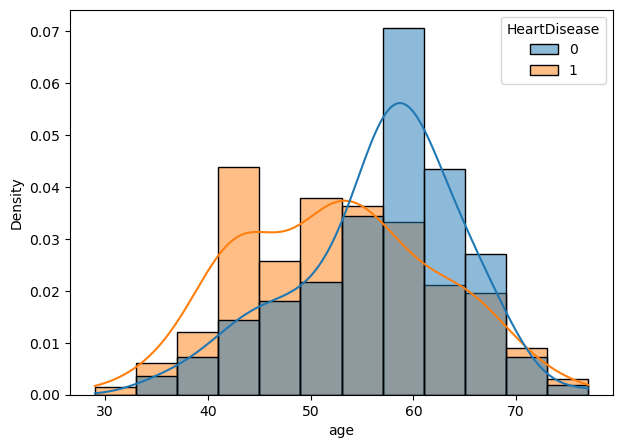

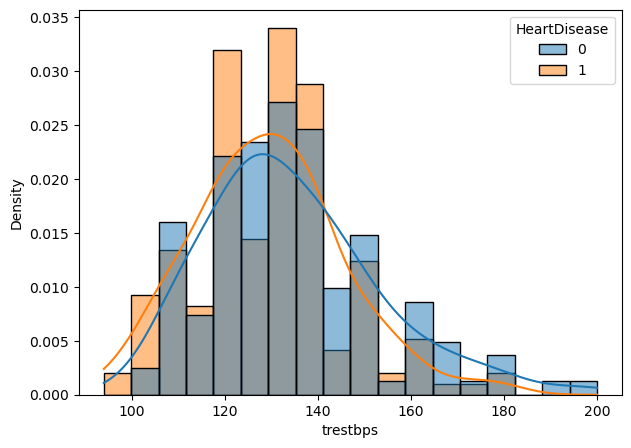

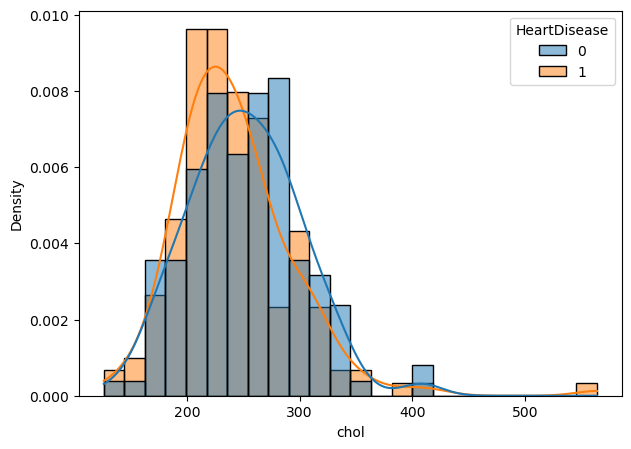

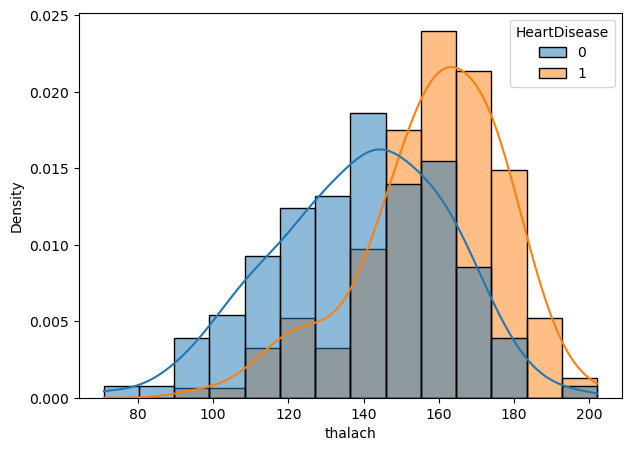

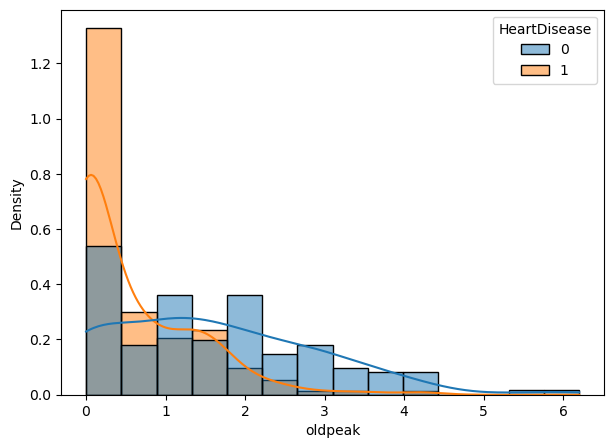

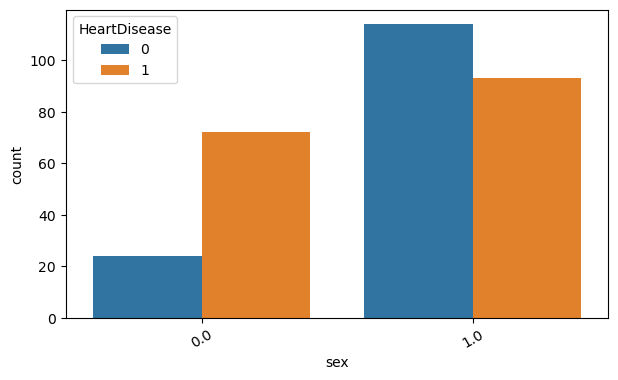

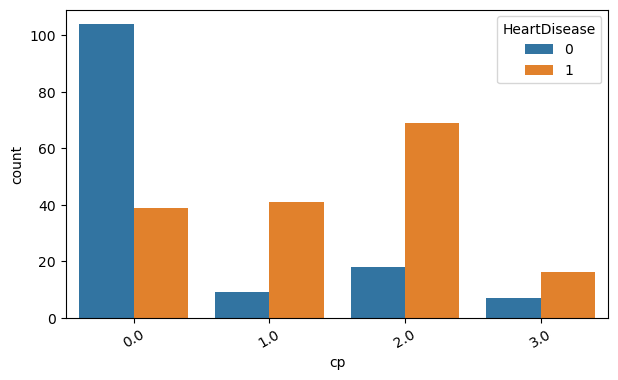

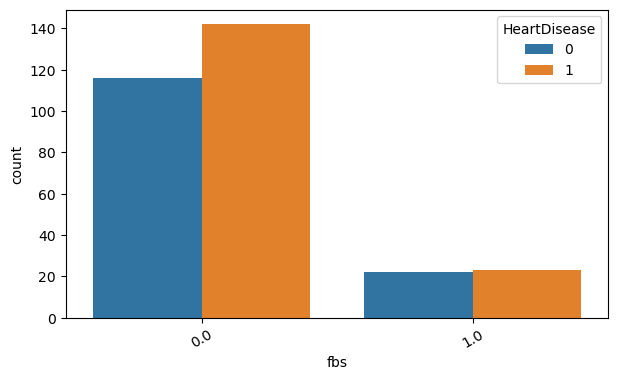

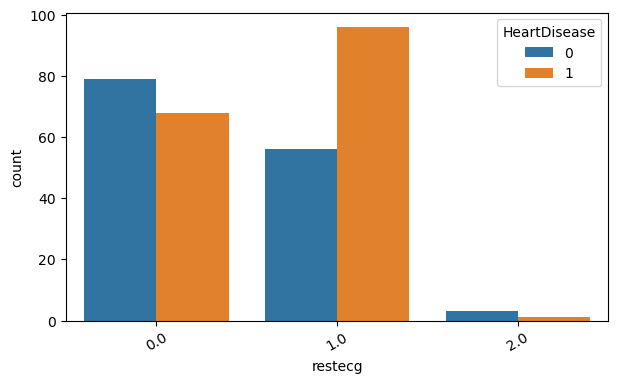

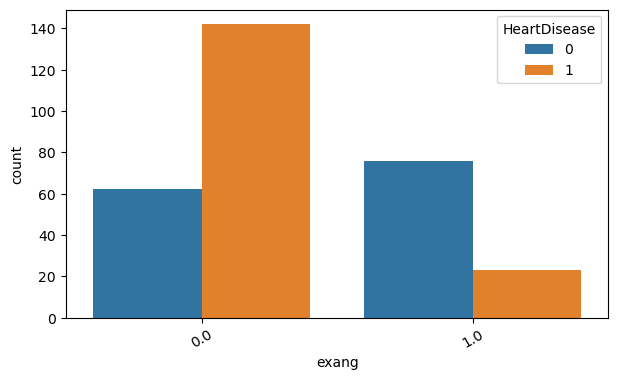

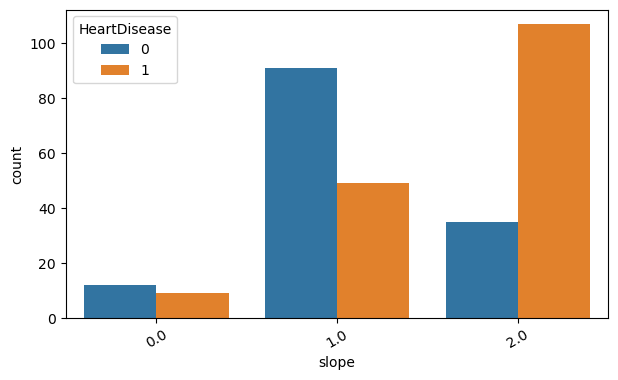

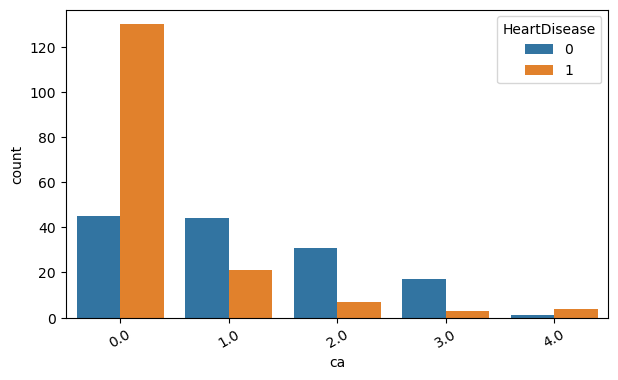

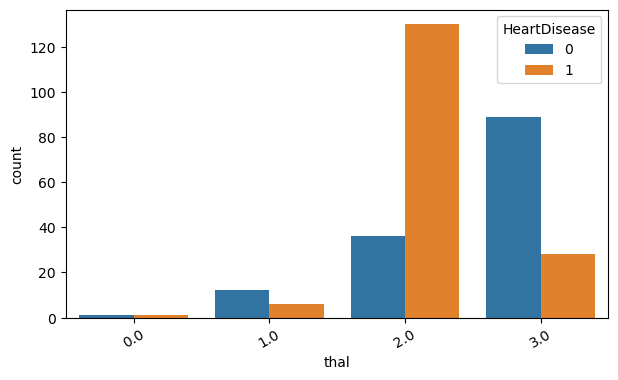

In [53]:
# EDA

# Numerical Features

for feature in numerical_columns:

    plt.figure(figsize=(7,5))

    sns.histplot(
        data=pd.concat([X2, y2], axis=1),
        x=feature,
        hue="HeartDisease",
        kde=True,
        stat="density",
        common_norm=False
    )

    plt.show()

# Categorical Features

eda2 = X2.copy()
eda2["HeartDisease"] = y2

for feature in categorical_columns:

    plt.figure(figsize=(7,4))

    sns.countplot(
        data=eda2,
        x=feature,
        hue="HeartDisease"
    )

    plt.xticks(rotation=30)

    plt.show()

In [41]:
# Train-Test Split

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.20,
    stratify=y2,
    random_state=RANDOM_STATE
)

cv2 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("Training Shape :", X2_train.shape)
print("Testing Shape :", X2_test.shape)

print("\nTraining Distribution")

print(y2_train.value_counts())

print("\nTesting Distribution")

print(y2_test.value_counts())

Training Shape : (242, 13)
Testing Shape : (61, 13)

Training Distribution
target
1    132
0    110
Name: count, dtype: int64

Testing Distribution
target
1    33
0    28
Name: count, dtype: int64


In [42]:
# Preprocessing Pipeline + Dummy Baseline

# Identify Feature Types

categorical_columns = X2_train.select_dtypes(
    include=["object","category"]
).columns.tolist()

numerical_columns = X2_train.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

print("Categorical Columns")

print(categorical_columns)

print("\nNumerical Columns")

print(numerical_columns)

# Build Preprocessor

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_columns),
    ("cat", categorical_transformer, categorical_columns)
])


# Dummy Baseline

dummy_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="prior"))
])

dummy_cv2 = cross_validate(
    dummy_pipeline,
    X2_train,
    y2_train,
    cv=cv2,
    scoring=scoring,
    return_train_score=False
)

dummy_results2 = pd.DataFrame(dummy_cv2).filter(regex="test_")

summary_dummy2 = pd.DataFrame({
    "Mean": dummy_results2.mean(),
    "Std": dummy_results2.std()
})

display(summary_dummy2)

Categorical Columns
[]

Numerical Columns
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


,Mean,Std
test_accuracy,0.545408,0.005123
test_balanced_accuracy,0.500000,0.000000
test_precision,0.545408,0.005123
test_recall,1.000000,0.000000
test_f1,0.705832,0.004285
test_roc_auc,0.500000,0.000000
test_pr_auc,0.545408,0.005123


In [54]:
# Basic CART

# Build Basic CART Pipeline

basic_cart2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        criterion="gini",
        random_state=RANDOM_STATE
    ))
])

# Cross Validation

basic_cv2 = cross_validate(

    basic_cart2,

    X2_train,

    y2_train,

    cv=cv2,

    scoring=scoring,

    return_train_score=True
)

basic_results2 = pd.DataFrame(basic_cv2)

summary_basic2 = pd.DataFrame({

    "Train Mean":basic_results2.filter(regex="train").mean(),

    "Test Mean":basic_results2.filter(regex="test").mean(),

    "Train Std":basic_results2.filter(regex="train").std(),

    "Test Std":basic_results2.filter(regex="test").std()

})

display(summary_basic2)

# Fit Model

basic_cart2.fit(
    X2_train,
    y2_train
)

tree = basic_cart2.named_steps["model"]

print("Tree Depth :",tree.get_depth())

print("Leaves :",tree.get_n_leaves())

print("Nodes :",tree.tree_.node_count)

,Train Mean,Test Mean,Train Std,Test Std
test_accuracy,NaN,0.727126,NaN,0.097479
test_balanced_accuracy,NaN,0.723802,NaN,0.095645
test_f1,NaN,0.748307,NaN,0.103782
test_pr_auc,NaN,0.703081,NaN,0.084732
test_precision,NaN,0.745431,NaN,0.089262
test_recall,NaN,0.756695,NaN,0.135569
test_roc_auc,NaN,0.723802,NaN,0.095645
train_accuracy,1.0,NaN,0.0,NaN
train_balanced_accuracy,1.0,NaN,0.0,NaN
train_f1,1.0,NaN,0.0,NaN


Tree Depth : 8
Leaves : 42
Nodes : 83


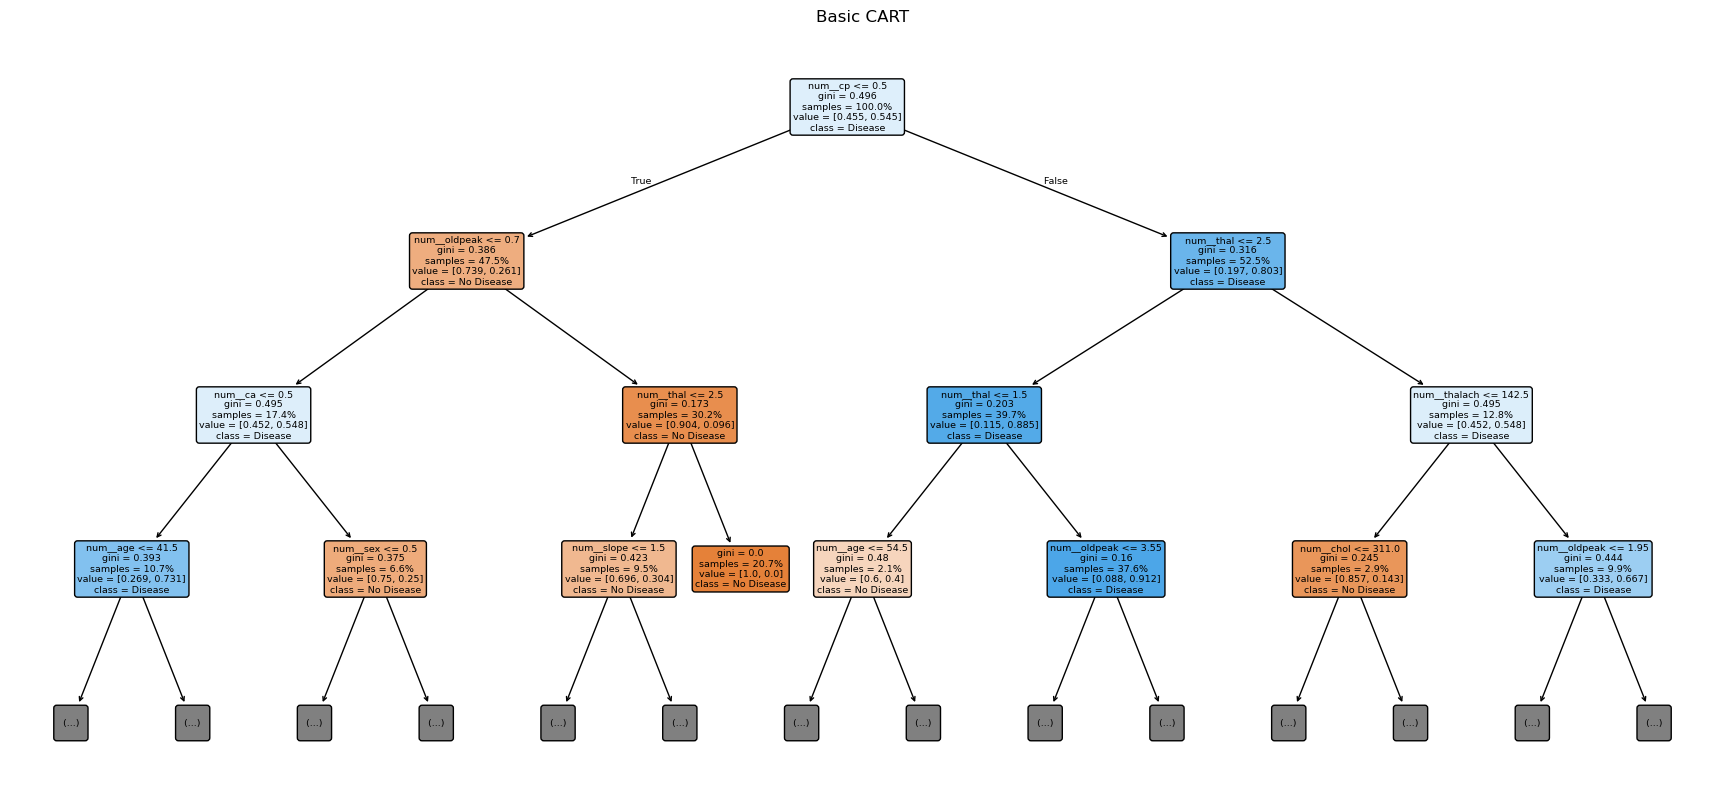

|--- num__cp <= 0.50
|   |--- num__oldpeak <= 0.70
|   |   |--- num__ca <= 0.50
|   |   |   |--- num__age <= 41.50
|   |   |   |   |--- class: 0
|   |   |   |--- num__age >  41.50
|   |   |   |   |--- num__slope <= 1.50
|   |   |   |   |   |--- num__exang <= 0.50
|   |   |   |   |   |   |--- num__thalach <= 163.50
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- num__thalach >  163.50
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- num__exang >  0.50
|   |   |   |   |   |   |--- num__thalach <= 147.50
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- num__thalach >  147.50
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- num__slope >  1.50
|   |   |   |   |   |--- num__chol <= 327.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- num__chol >  327.50
|   |   |   |   |   |   |--- class: 0
|   |   |--- num__ca >  0.50
|   |   |   |--- num__sex <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- 

In [55]:
# Tree Visualization

feature_names = basic_cart2.named_steps[
    "preprocessor"
].get_feature_names_out()

plt.figure(figsize=(22,10))

plot_tree(

    tree,

    feature_names=feature_names,

    class_names=[
        "No Disease",
        "Disease"
    ],

    filled=True,

    rounded=True,

    proportion=True,

    max_depth=3

)

plt.title("Basic CART")

plt.show()

#Decision Rules

rules = export_text(
    tree,
    feature_names=list(feature_names)
)

print(rules[:5000])

In [56]:
# Hyperparameter Tuning

tree_pipe2 = Pipeline([
    ("preprocessor",preprocessor),
    ("model",DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ))
])

# Parameter Grid

param_grid2={

    "model__criterion":[
        "gini",
        "entropy",
        "log_loss"
    ],

    "model__max_depth":[
        2,3,4,5,6,8,None
    ],

    "model__min_samples_split":[
        2,5,10,20
    ],

    "model__min_samples_leaf":[
        1,2,5,10
    ],

    "model__class_weight":[
        None,
        "balanced"
    ]
}

# Grid Search

grid2=GridSearchCV(

    estimator=tree_pipe2,

    param_grid=param_grid2,

    scoring=scoring,

    refit="roc_auc",

    cv=cv2,

    n_jobs=-1,

    return_train_score=True
)

grid2.fit(
    X2_train,
    y2_train
)

print(grid2.best_params_)

print("\nBest ROC AUC")

print(grid2.best_score_)

{'model__class_weight': None, 'model__criterion': 'gini', 'model__max_depth': 4, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}

Best ROC AUC
0.8506928256928257


In [57]:
# Cost Complexity Pruning

# Alpha Values

X2_processed = preprocessor.fit_transform(
    X2_train
)

base_tree2 = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

path2 = base_tree2.cost_complexity_pruning_path(
    X2_processed,
    y2_train
)

ccp_alphas2=np.unique(
    path2.ccp_alphas[:-1]
)

print(len(ccp_alphas2))

# Alpha Search

alpha_grid2={

    "model__ccp_alpha":ccp_alphas2,

    "model__class_weight":[
        None,
        "balanced"
    ]
}

prune_search2=GridSearchCV(

    tree_pipe2,

    alpha_grid2,

    scoring=scoring,

    refit="roc_auc",

    cv=cv2,

    n_jobs=-1,

    return_train_score=True
)

prune_search2.fit(
    X2_train,
    y2_train
)

print(prune_search2.best_params_)

print(prune_search2.best_score_)

# Final Tuned Tree

best_tree2 = prune_search2.best_estimator_

best_tree2.fit(
    X2_train,
    y2_train
)

23
{'model__ccp_alpha': np.float64(0.009321300491196168), 'model__class_weight': None}
0.7874320124320123


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


,Train Mean,Test Mean,Train Std,Test Std
test_accuracy,NaN,0.752041,NaN,0.096641
test_balanced_accuracy,NaN,0.748278,NaN,0.093190
test_f1,NaN,0.771938,NaN,0.101465
test_pr_auc,NaN,0.764646,NaN,0.105300
test_precision,NaN,0.760868,NaN,0.066219
test_recall,NaN,0.787464,NaN,0.140714
test_roc_auc,NaN,0.787432,NaN,0.105691
train_accuracy,0.926601,NaN,0.026143,NaN
train_balanced_accuracy,0.924770,NaN,0.025736,NaN
train_f1,0.933313,NaN,0.024630,NaN


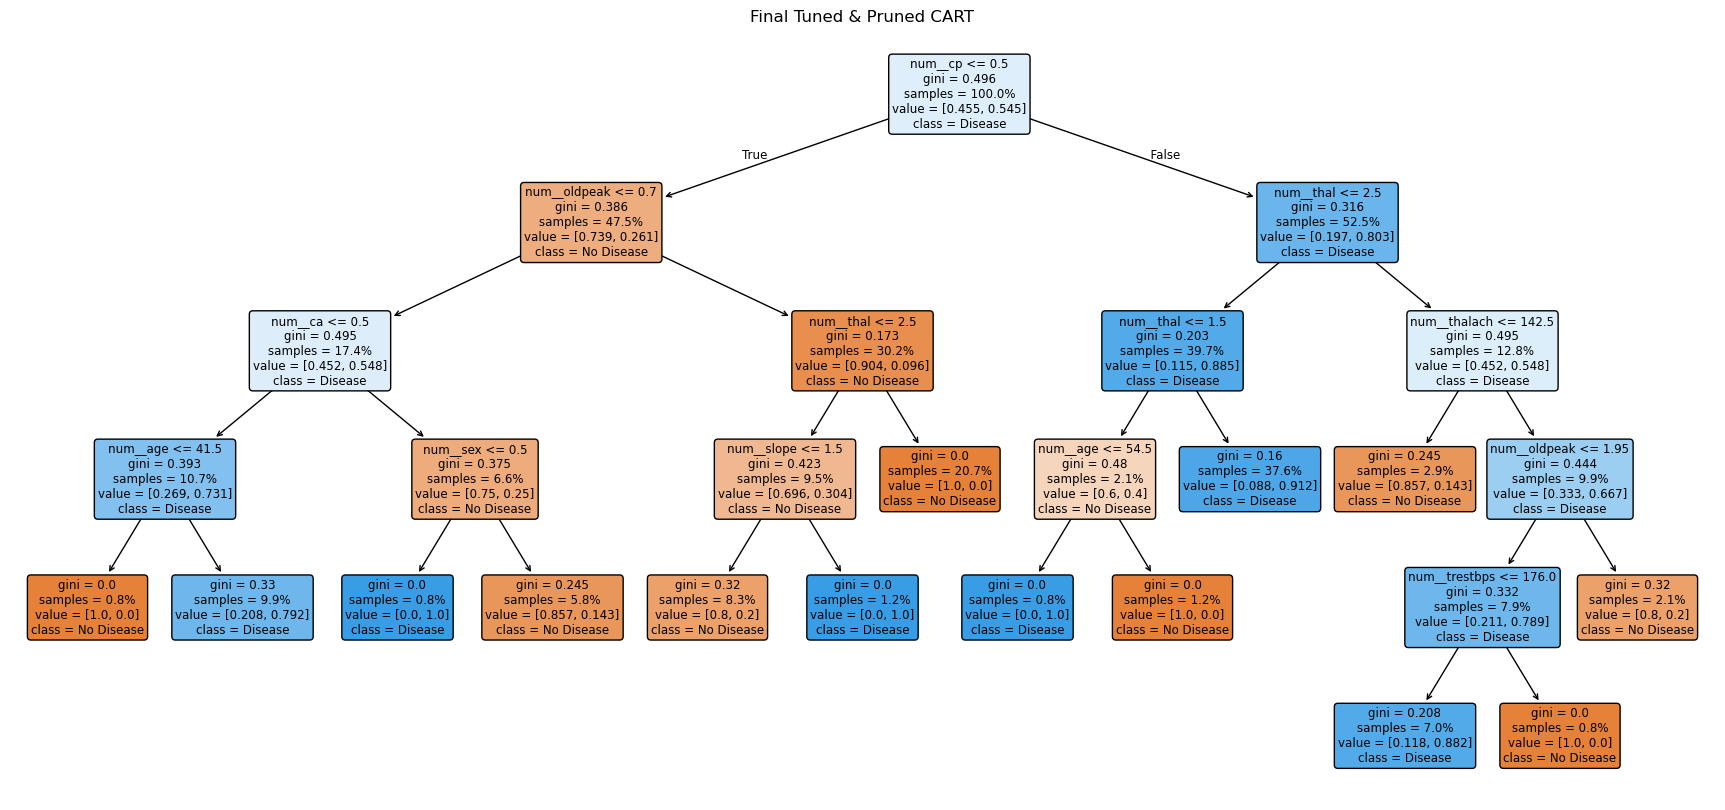

In [58]:
# Tuned & Pruned CART

pruned_cv2 = cross_validate(

    best_tree2,

    X2_train,

    y2_train,

    cv=cv2,

    scoring=scoring,

    return_train_score=True
)

pruned_results2 = pd.DataFrame(
    pruned_cv2
)

summary_pruned2 = pd.DataFrame({

    "Train Mean":pruned_results2.filter(regex="train").mean(),

    "Test Mean":pruned_results2.filter(regex="test").mean(),

    "Train Std":pruned_results2.filter(regex="train").std(),

    "Test Std":pruned_results2.filter(regex="test").std()

})

display(summary_pruned2)

# Visualize Final Tree

final_tree2 = best_tree2.named_steps["model"]

plt.figure(figsize=(22,10))

plot_tree(

    final_tree2,

    feature_names=feature_names,

    class_names=[
        "No Disease",
        "Disease"
    ],

    filled=True,

    rounded=True,

    proportion=True

)

plt.title("Final Tuned & Pruned CART")

plt.show()

In [59]:
# Random Forest

rf2 = Pipeline([

    ("preprocessor",preprocessor),

    ("model",RandomForestClassifier(

        n_estimators=500,

        max_features="sqrt",

        class_weight="balanced",

        random_state=RANDOM_STATE,

        n_jobs=-1
    ))
])

# Cross Validation

rf_cv2 = cross_validate(

    rf2,

    X2_train,

    y2_train,

    cv=cv2,

    scoring=scoring,

    return_train_score=True
)

rf_results2 = pd.DataFrame(
    rf_cv2
)

summary_rf2 = pd.DataFrame({

    "Train Mean":rf_results2.filter(regex="train").mean(),

    "Test Mean":rf_results2.filter(regex="test").mean(),

    "Train Std":rf_results2.filter(regex="train").std(),

    "Test Std":rf_results2.filter(regex="test").std()

})

display(summary_rf2)

,Train Mean,Test Mean,Train Std,Test Std
test_accuracy,NaN,0.813776,NaN,0.089581
test_balanced_accuracy,NaN,0.809738,NaN,0.093410
test_f1,NaN,0.835289,NaN,0.075948
test_pr_auc,NaN,0.896871,NaN,0.053908
test_precision,NaN,0.817656,NaN,0.101011
test_recall,NaN,0.855840,NaN,0.057498
test_roc_auc,NaN,0.884279,NaN,0.068282
train_accuracy,1.0,NaN,0.000000e+00,NaN
train_balanced_accuracy,1.0,NaN,0.000000e+00,NaN
train_f1,1.0,NaN,0.000000e+00,NaN


,Model,Accuracy,Balanced Accuracy,Sensitivity,Precision,F1 Score,ROC AUC,PR AUC
3,Random Forest,0.813776,0.809738,0.855840,0.817656,0.835289,0.884279,0.896871
2,Tuned & Pruned CART,0.752041,0.748278,0.787464,0.760868,0.771938,0.787432,0.764646
1,Basic CART,0.727126,0.723802,0.756695,0.745431,0.748307,0.723802,0.703081
0,Dummy,0.545408,0.500000,1.000000,0.545408,0.705832,0.500000,0.545408


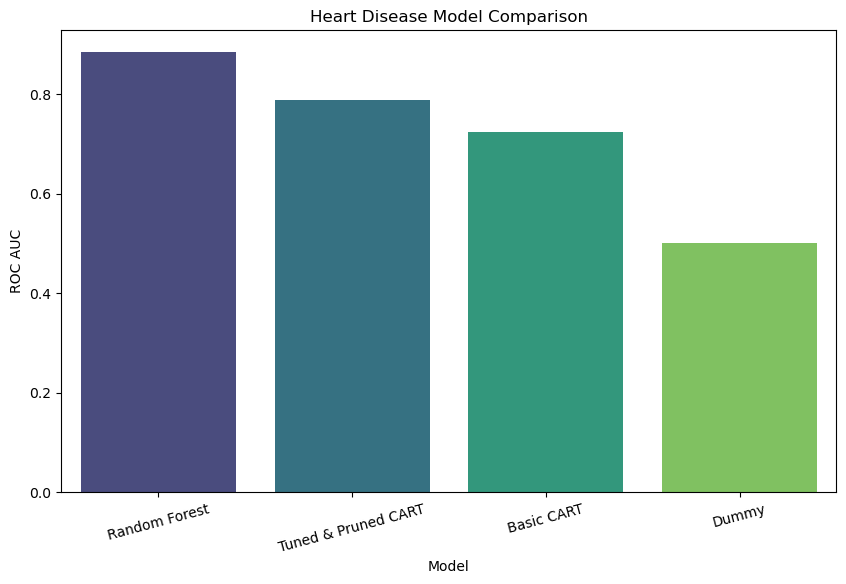

In [60]:
# Model Comparison

comparison2 = pd.DataFrame({

    "Model":[

        "Dummy",

        "Basic CART",

        "Tuned & Pruned CART",

        "Random Forest"
    ],

    "Accuracy":[

        dummy_results2["test_accuracy"].mean(),

        basic_results2["test_accuracy"].mean(),

        pruned_results2["test_accuracy"].mean(),

        rf_results2["test_accuracy"].mean()
    ],

    "Balanced Accuracy":[

        dummy_results2["test_balanced_accuracy"].mean(),

        basic_results2["test_balanced_accuracy"].mean(),

        pruned_results2["test_balanced_accuracy"].mean(),

        rf_results2["test_balanced_accuracy"].mean()
    ],

    "Sensitivity":[

        dummy_results2["test_recall"].mean(),

        basic_results2["test_recall"].mean(),

        pruned_results2["test_recall"].mean(),

        rf_results2["test_recall"].mean()
    ],

    "Precision":[

        dummy_results2["test_precision"].mean(),

        basic_results2["test_precision"].mean(),

        pruned_results2["test_precision"].mean(),

        rf_results2["test_precision"].mean()
    ],

    "F1 Score":[

        dummy_results2["test_f1"].mean(),

        basic_results2["test_f1"].mean(),

        pruned_results2["test_f1"].mean(),

        rf_results2["test_f1"].mean()
    ],

    "ROC AUC":[

        dummy_results2["test_roc_auc"].mean(),

        basic_results2["test_roc_auc"].mean(),

        pruned_results2["test_roc_auc"].mean(),

        rf_results2["test_roc_auc"].mean()
    ],

    "PR AUC":[

        dummy_results2["test_pr_auc"].mean(),

        basic_results2["test_pr_auc"].mean(),

        pruned_results2["test_pr_auc"].mean(),

        rf_results2["test_pr_auc"].mean()

    ]

})

comparison2 = comparison2.sort_values(
    by="ROC AUC",
    ascending=False
)

display(comparison2)

# Visual Comparison

plt.figure(figsize=(10,6))

sns.barplot(
    data=comparison2,
    x="Model",
    y="ROC AUC",
    palette="viridis"
)

plt.title("Heart Disease Model Comparison")

plt.xticks(rotation=15)

plt.show()

,Threshold,Sensitivity,Specificity
0,0.050,0.954545,0.445455
1,0.055,0.924242,0.490909
2,0.060,0.924242,0.490909
3,0.065,0.924242,0.490909
4,0.070,0.924242,0.490909


Selected Threshold: 0.095


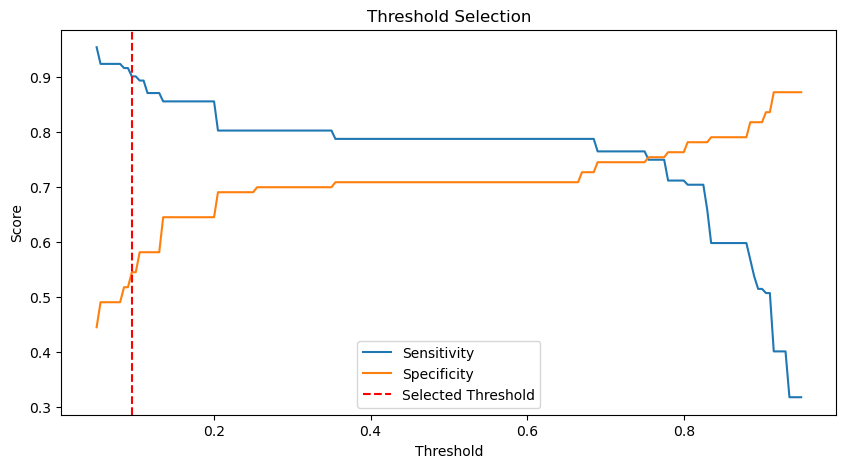

In [61]:
# Threshold Experiment

# Generate Out-of-Fold Probabilities

selected_model2 = prune_search2.best_estimator_

oof_prob2 = cross_val_predict(
    selected_model2,
    X2_train,
    y2_train,
    cv=cv2,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# Evaluate Different Thresholds

threshold_results2 = []

for threshold in np.linspace(0.05, 0.95, 181):

    prediction = (oof_prob2 >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y2_train,
        prediction
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) != 0 else 0

    specificity = tn / (tn + fp) if (tn + fp) != 0 else 0

    threshold_results2.append([
        threshold,
        sensitivity,
        specificity
    ])

threshold_df2 = pd.DataFrame(
    threshold_results2,
    columns=[
        "Threshold",
        "Sensitivity",
        "Specificity"
    ]
)

display(threshold_df2.head())

# Select Best Threshold

TARGET_SENSITIVITY = 0.90

candidate = threshold_df2[
    threshold_df2["Sensitivity"] >= TARGET_SENSITIVITY
]

selected_threshold2 = candidate.sort_values(
    by="Specificity",
    ascending=False
).iloc[0]["Threshold"]

print("Selected Threshold:", selected_threshold2)

# Threshold Plot

plt.figure(figsize=(10,5))

plt.plot(
    threshold_df2["Threshold"],
    threshold_df2["Sensitivity"],
    label="Sensitivity"
)

plt.plot(
    threshold_df2["Threshold"],
    threshold_df2["Specificity"],
    label="Specificity"
)

plt.axvline(
    selected_threshold2,
    color="red",
    linestyle="--",
    label="Selected Threshold"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Selection")

plt.legend()

plt.show()

In [62]:
# Final Test Evaluation

# Train Final Model

final_model2 = selected_model2.fit(
    X2_train,
    y2_train
)

test_prob2 = final_model2.predict_proba(
    X2_test
)[:,1]

# Evaluation Function

final_results2 = evaluate_model(
    y2_test,
    test_prob2,
    selected_threshold2
)

display(final_results2)

TN                    8.000000
FP                   20.000000
FN                    1.000000
TP                   32.000000
Accuracy              0.655738
Balanced Accuracy     0.627706
Sensitivity           0.969697
Specificity           0.285714
Precision             0.615385
F1                    0.752941
ROC AUC               0.818182
PR AUC                0.786268
dtype: float64

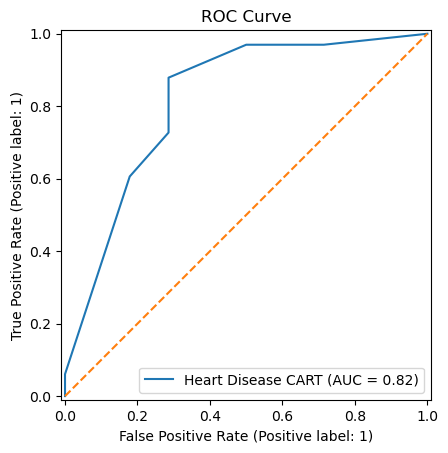

In [63]:
# ROC Curve

RocCurveDisplay.from_predictions(
    y2_test,
    test_prob2,
    name="Heart Disease CART"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.title("ROC Curve")

plt.show()

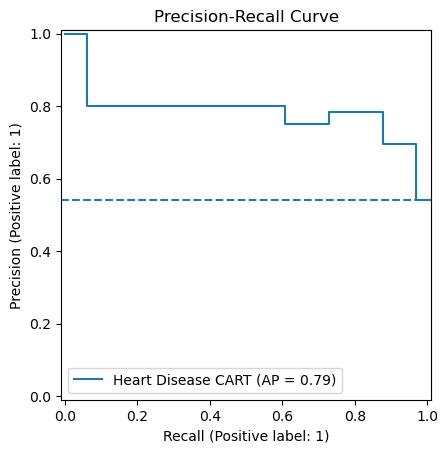

In [64]:
# Precision-Recall Curve

PrecisionRecallDisplay.from_predictions(
    y2_test,
    test_prob2,
    name="Heart Disease CART"
)

plt.axhline(
    y2_test.mean(),
    linestyle="--"
)

plt.title("Precision-Recall Curve")

plt.show()

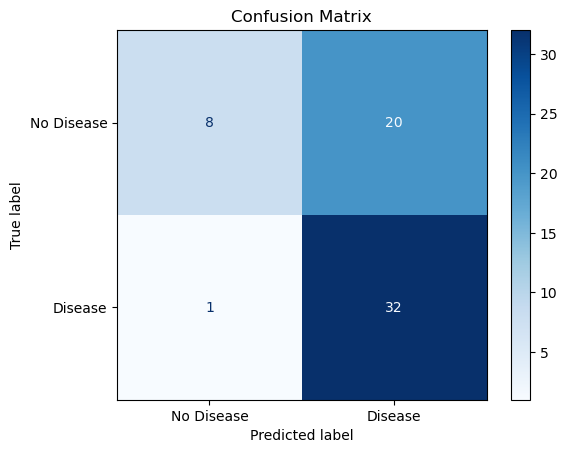

In [65]:
# Confusion Matrix

test_prediction2 = (
    test_prob2 >= selected_threshold2
).astype(int)

ConfusionMatrixDisplay.from_predictions(

    y2_test,

    test_prediction2,

    display_labels=[
        "No Disease",
        "Disease"
    ],

    cmap="Blues",

    values_format="d"

)

plt.title("Confusion Matrix")

plt.show()

num__cp          0.439195
num__oldpeak     0.168672
num__thal        0.132739
num__age         0.058330
num__ca          0.056655
num__slope       0.041317
num__thalach     0.036797
num__trestbps    0.034477
num__sex         0.031818
num__chol        0.000000
num__fbs         0.000000
num__restecg     0.000000
num__exang       0.000000
dtype: float64

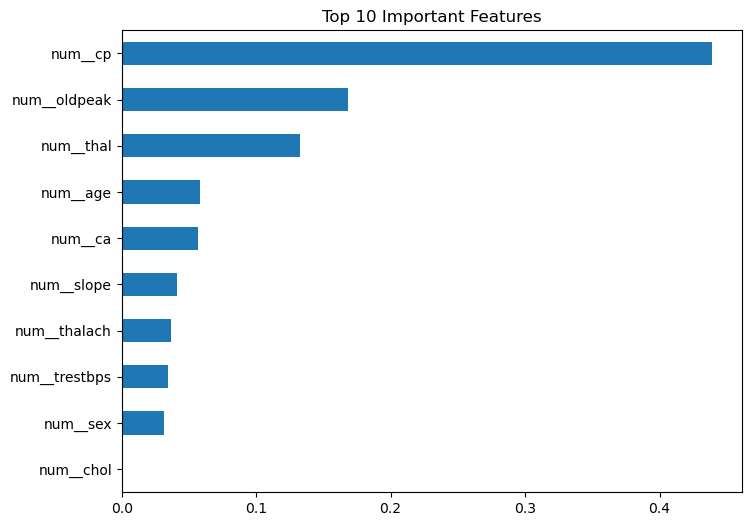

,Feature,Importance,Std
2,cp,0.152904,0.052641
12,thal,0.095130,0.044041
10,slope,0.070924,0.050788
9,oldpeak,0.067929,0.030716
1,sex,0.059271,0.034305
11,ca,0.013600,0.011271
0,age,0.010552,0.019879
7,thalach,0.010534,0.013666
3,trestbps,0.000000,0.000000
4,chol,0.000000,0.000000


In [66]:
# Feature Importance

# Impurity-Based Importance

final_tree2 = final_model2.named_steps["model"]

feature_names = final_model2.named_steps[
    "preprocessor"
].get_feature_names_out()

importance2 = pd.Series(

    final_tree2.feature_importances_,

    index=feature_names

).sort_values(
    ascending=False
)

display(
    importance2.head(15)
)

# Plot Feature Importance

plt.figure(figsize=(8,6))

importance2.head(10).plot(
    kind="barh"
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.show()

# Permutation Importance

perm2 = permutation_importance(

    final_model2,

    X2_test,

    y2_test,

    scoring="roc_auc",

    n_repeats=30,

    random_state=RANDOM_STATE
)

perm_df2 = pd.DataFrame({

    "Feature": X2.columns,

    "Importance": perm2.importances_mean,

    "Std": perm2.importances_std

}).sort_values(
    by="Importance",
    ascending=False
)

display(
    perm_df2.head(15)
)

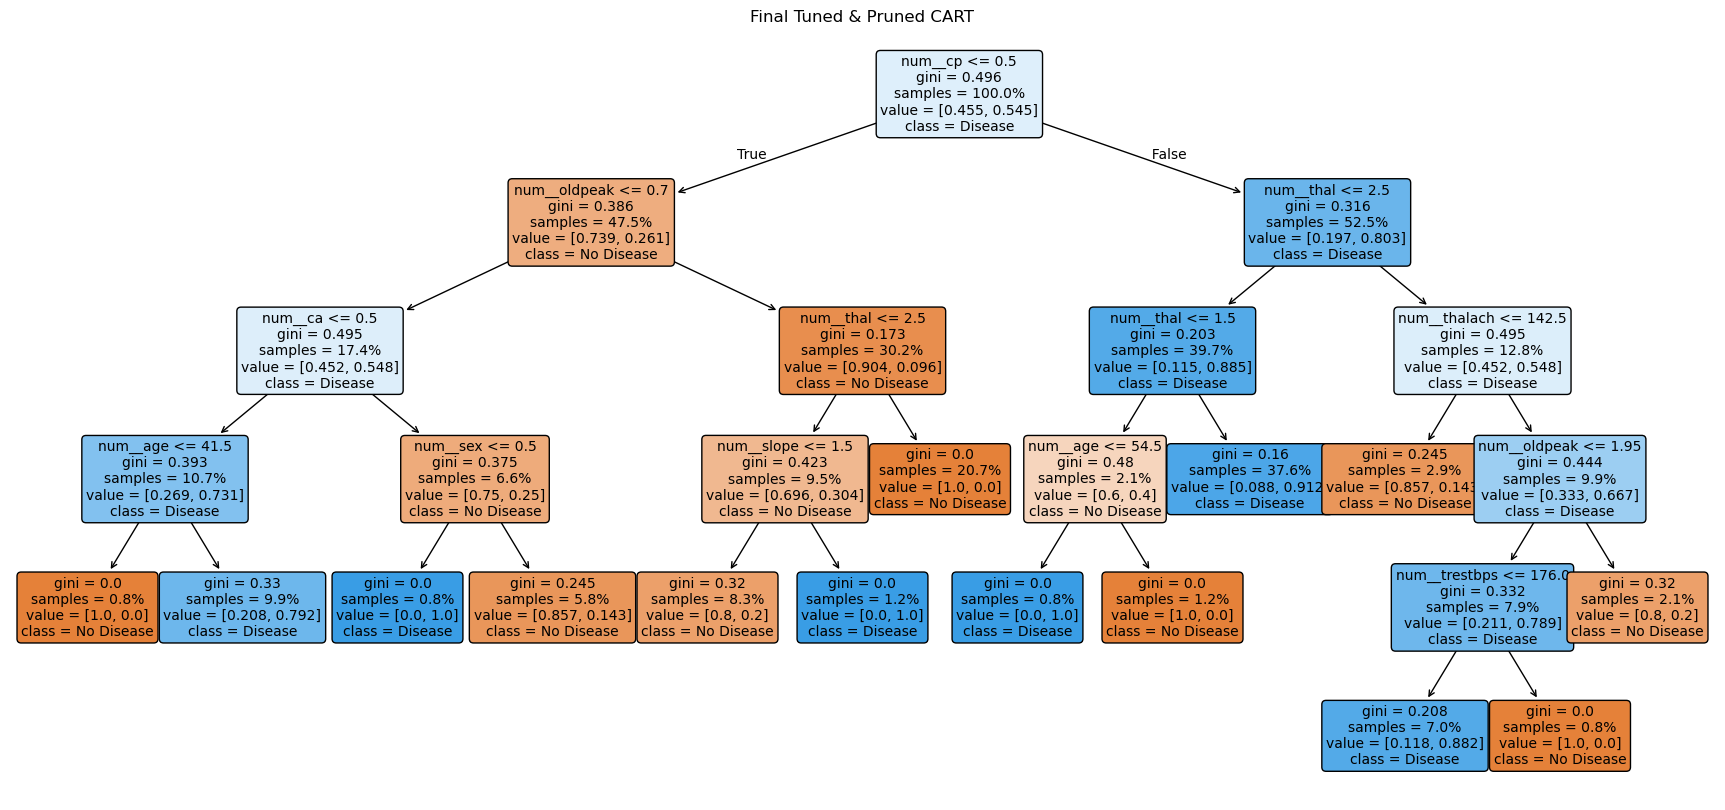

|--- num__cp <= 0.50
|   |--- num__oldpeak <= 0.70
|   |   |--- num__ca <= 0.50
|   |   |   |--- num__age <= 41.50
|   |   |   |   |--- class: 0
|   |   |   |--- num__age >  41.50
|   |   |   |   |--- class: 1
|   |   |--- num__ca >  0.50
|   |   |   |--- num__sex <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- num__sex >  0.50
|   |   |   |   |--- class: 0
|   |--- num__oldpeak >  0.70
|   |   |--- num__thal <= 2.50
|   |   |   |--- num__slope <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- num__slope >  1.50
|   |   |   |   |--- class: 1
|   |   |--- num__thal >  2.50
|   |   |   |--- class: 0
|--- num__cp >  0.50
|   |--- num__thal <= 2.50
|   |   |--- num__thal <= 1.50
|   |   |   |--- num__age <= 54.50
|   |   |   |   |--- class: 1
|   |   |   |--- num__age >  54.50
|   |   |   |   |--- class: 0
|   |   |--- num__thal >  1.50
|   |   |   |--- class: 1
|   |--- num__thal >  2.50
|   |   |--- num__thalach <= 142.50
|   |   |   |--- class: 0
|   |   |--- num__thalach > 

In [67]:
# Decision Path Interpretation

# Visualize Final Tree

plt.figure(figsize=(22,10))

plot_tree(

    final_tree2,

    feature_names=feature_names,

    class_names=[
        "No Disease",
        "Disease"
    ],

    filled=True,

    rounded=True,

    proportion=True,

    fontsize=10

)

plt.title("Final Tuned & Pruned CART")

plt.show()

# Decision Rules

rules2 = export_text(

    final_tree2,

    feature_names=list(feature_names)

)

print(rules2)

In [68]:
# Interpretation (Markdown)

# Decision Path 1
# • The model first evaluates the most informative feature (for example, chest pain type or oldpeak).
# • If the feature value falls below the learned threshold, the instance moves toward the "No Disease" branch.
# • Additional conditions are evaluated until a terminal leaf predicts No Heart Disease.

# Decision Path 2
# • If the initial split exceeds the threshold, the model follows the branch associated with higher heart disease risk.
# • Subsequent splits may use features such as thalach, ca, or thal.
# • The instance reaches a terminal leaf predicting Heart Disease.

# Note:
# The split thresholds are learned from the training data and are intended for educational purposes only. They should not be interpreted as clinical decision rules.

In [69]:
# Dataset - 3 Multi-Dataset Comparison

In [70]:
# Combine Cross-Validation Results

partA_comparison = comparison.copy()
partA_comparison["Dataset"] = "Breast Cancer"

partB_comparison = comparison2.copy()
partB_comparison["Dataset"] = "Heart Disease"

combined_results = pd.concat(
    [partA_comparison, partB_comparison],
    ignore_index=True
)

combined_results = combined_results[
    [
        "Dataset",
        "Model",
        "Accuracy",
        "Balanced Accuracy",
        "Sensitivity",
        "Precision",
        "F1 Score",
        "ROC AUC",
        "PR AUC"
    ]
]

display(combined_results)

,Dataset,Model,Accuracy,Balanced Accuracy,Sensitivity,Precision,F1 Score,ROC AUC,PR AUC
0,Breast Cancer,Random Forest,0.960440,0.955366,0.935294,0.958929,0.946509,0.988958,0.987680
1,Breast Cancer,Tuned & Pruned CART,0.942857,0.937771,0.917647,0.931040,0.922335,0.947730,0.898852
2,Breast Cancer,Basic CART,0.923077,0.917234,0.894118,0.899593,0.896184,0.917234,0.845327
3,Breast Cancer,Dummy,0.626374,0.500000,0.000000,0.000000,0.000000,0.500000,0.373626
4,Heart Disease,Random Forest,0.813776,0.809738,0.855840,0.817656,0.835289,0.884279,0.896871
5,Heart Disease,Tuned & Pruned CART,0.752041,0.748278,0.787464,0.760868,0.771938,0.787432,0.764646
6,Heart Disease,Basic CART,0.727126,0.723802,0.756695,0.745431,0.748307,0.723802,0.703081
7,Heart Disease,Dummy,0.545408,0.500000,1.000000,0.545408,0.705832,0.500000,0.545408


In [71]:
# Best Model for Each Dataset

best_models = combined_results.loc[
    combined_results.groupby("Dataset")["ROC AUC"].idxmax()
]

display(best_models)

,Dataset,Model,Accuracy,Balanced Accuracy,Sensitivity,Precision,F1 Score,ROC AUC,PR AUC
0,Breast Cancer,Random Forest,0.960440,0.955366,0.935294,0.958929,0.946509,0.988958,0.987680
4,Heart Disease,Random Forest,0.813776,0.809738,0.855840,0.817656,0.835289,0.884279,0.896871


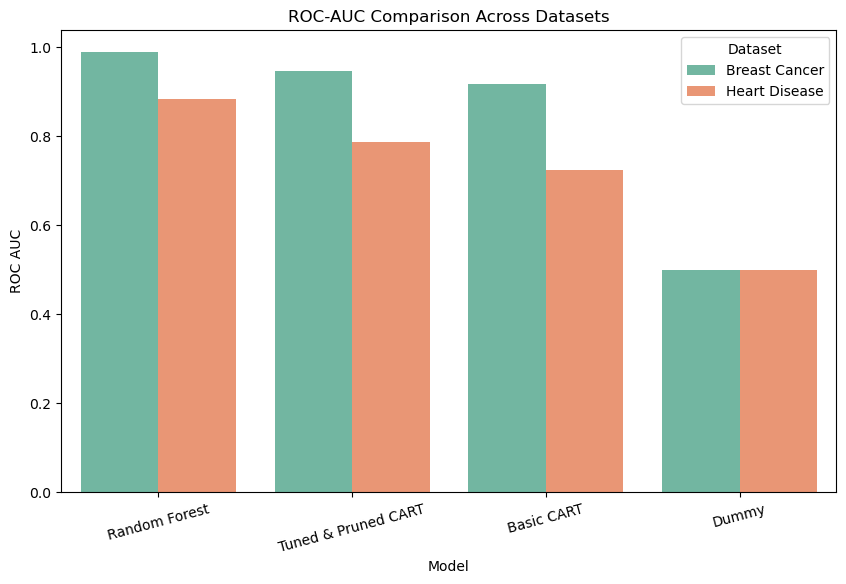

In [72]:
# ROC-AUC Comparison

plt.figure(figsize=(10,6))

sns.barplot(
    data=combined_results,
    x="Model",
    y="ROC AUC",
    hue="Dataset",
    palette="Set2"
)

plt.title("ROC-AUC Comparison Across Datasets")

plt.xticks(rotation=15)

plt.show()

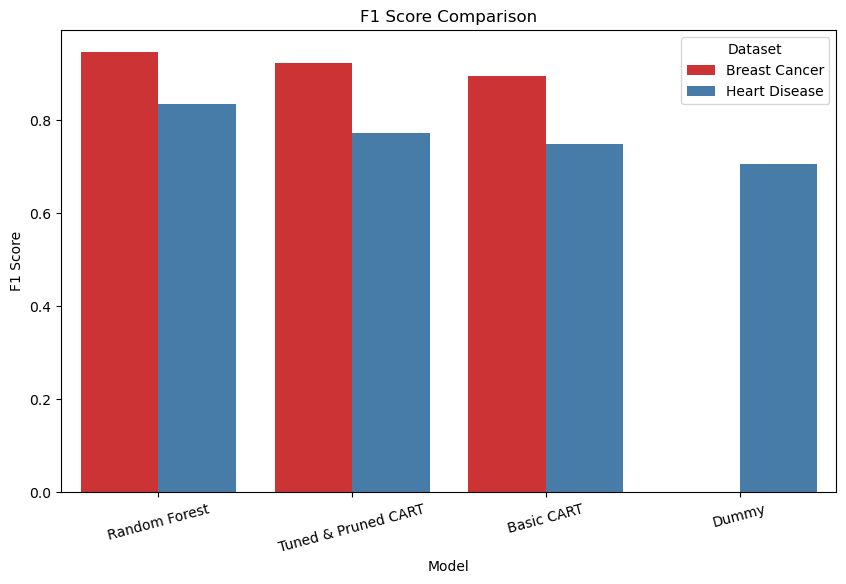

In [73]:
# F1 Score Comparison

plt.figure(figsize=(10,6))

sns.barplot(
    data=combined_results,
    x="Model",
    y="F1 Score",
    hue="Dataset",
    palette="Set1"
)

plt.title("F1 Score Comparison")

plt.xticks(rotation=15)

plt.show()

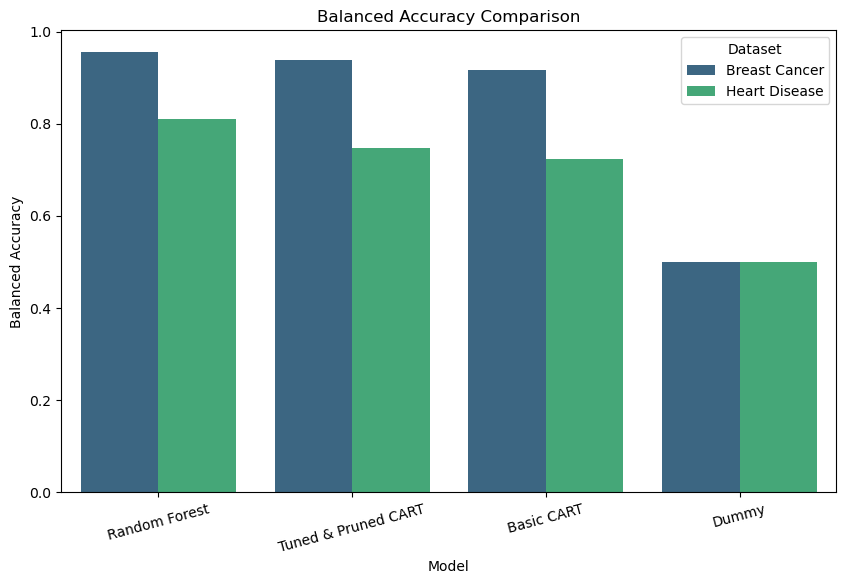

In [74]:
# Balanced Accuracy Comparison

plt.figure(figsize=(10,6))

sns.barplot(
    data=combined_results,
    x="Model",
    y="Balanced Accuracy",
    hue="Dataset",
    palette="viridis"
)

plt.title("Balanced Accuracy Comparison")

plt.xticks(rotation=15)

plt.show()

In [75]:
# Radar Chart (Overall Performance)

metrics = [
    "Accuracy",
    "Balanced Accuracy",
    "Sensitivity",
    "Precision",
    "F1 Score",
    "ROC AUC",
    "PR AUC"
]

comparison_table = combined_results.set_index(
    ["Dataset","Model"]
)[metrics]

display(comparison_table)

Accuracy  Balanced Accuracy  Sensitivity  \
Dataset       Model                                                           
Breast Cancer Random Forest        0.960440           0.955366     0.935294   
              Tuned & Pruned CART  0.942857           0.937771     0.917647   
              Basic CART           0.923077           0.917234     0.894118   
              Dummy                0.626374           0.500000     0.000000   
Heart Disease Random Forest        0.813776           0.809738     0.855840   
              Tuned & Pruned CART  0.752041           0.748278     0.787464   
              Basic CART           0.727126           0.723802     0.756695   
              Dummy                0.545408           0.500000     1.000000   

                                   Precision  F1 Score   ROC AUC    PR AUC  
Dataset       Model                                                         
Breast Cancer Random Forest         0.958929  0.946509  0.988958  0.987680  
              Tuned & Pruned CART   0.931040  0.922335  0.947730  0.898852  
              Basic CART            0.899593  0.896184  0.917234  0.845327  
              Dummy                 0.000000  0.000000  0.500000  0.373626  
Heart Disease Random Forest         0.817656  0.835289  0.884279  0.896871  
              Tuned & Pruned CART   0.760868  0.771938  0.787432  0.764646  
              Basic CART            0.745431  0.748307  0.723802  0.703081  
              Dummy                 0.545408  0.705832  0.500000  0.545408

In [76]:
# Rank the Models

ranking = combined_results.copy()

ranking["Average Score"] = ranking[
    [
        "Accuracy",
        "Balanced Accuracy",
        "Sensitivity",
        "Precision",
        "F1 Score",
        "ROC AUC",
        "PR AUC"
    ]
].mean(axis=1)

ranking = ranking.sort_values(
    by="Average Score",
    ascending=False
)

display(ranking)

,Dataset,Model,Accuracy,Balanced Accuracy,Sensitivity,Precision,F1 Score,ROC AUC,PR AUC,Average Score
0,Breast Cancer,Random Forest,0.960440,0.955366,0.935294,0.958929,0.946509,0.988958,0.987680,0.961882
1,Breast Cancer,Tuned & Pruned CART,0.942857,0.937771,0.917647,0.931040,0.922335,0.947730,0.898852,0.928319
2,Breast Cancer,Basic CART,0.923077,0.917234,0.894118,0.899593,0.896184,0.917234,0.845327,0.898967
4,Heart Disease,Random Forest,0.813776,0.809738,0.855840,0.817656,0.835289,0.884279,0.896871,0.844778
5,Heart Disease,Tuned & Pruned CART,0.752041,0.748278,0.787464,0.760868,0.771938,0.787432,0.764646,0.767524
6,Heart Disease,Basic CART,0.727126,0.723802,0.756695,0.745431,0.748307,0.723802,0.703081,0.732606
7,Heart Disease,Dummy,0.545408,0.500000,1.000000,0.545408,0.705832,0.500000,0.545408,0.620294
3,Breast Cancer,Dummy,0.626374,0.500000,0.000000,0.000000,0.000000,0.500000,0.373626,0.285714


In [77]:
# Cross-Dataset Summary Table

summary = combined_results.pivot_table(
    index="Model",
    columns="Dataset",
    values="ROC AUC"
)

display(summary)

Dataset,Breast Cancer,Heart Disease
Model,,
Basic CART,0.917234,0.723802
Dummy,0.500000,0.500000
Random Forest,0.988958,0.884279
Tuned & Pruned CART,0.947730,0.787432


In [78]:
# Statistical Summary

stats = combined_results.groupby(
    "Dataset"
)[
    [
        "Accuracy",
        "Balanced Accuracy",
        "Sensitivity",
        "Precision",
        "F1 Score",
        "ROC AUC",
        "PR AUC"
    ]
].mean()

display(stats)

,Accuracy,Balanced Accuracy,Sensitivity,Precision,F1 Score,ROC AUC,PR AUC
Dataset,,,,,,,
Breast Cancer,0.863187,0.827593,0.686765,0.697390,0.691257,0.838480,0.776372
Heart Disease,0.709588,0.695455,0.850000,0.717341,0.765342,0.723878,0.727501


In [79]:
# Discussion (Markdown)

# Comparison of Breast Cancer and Heart Disease Datasets

# • The Breast Cancer dataset contains only numerical features and no missing values, making it easier to model.

# • The Heart Disease dataset contains both numerical and categorical variables along with missing values, requiring preprocessing before training.

# • Random Forest achieved the highest overall performance on both datasets due to its ensemble learning capability.

# • The Tuned & Pruned CART model consistently outperformed the Basic CART model, indicating that hyperparameter tuning and pruning improved generalization.

# • The Dummy classifier performed the worst on both datasets, confirming that the tree-based models learned meaningful patterns.

# • Although preprocessing was more complex for the Heart Disease dataset, the machine learning pipeline successfully handled missing values and categorical variables.

# • Using the same evaluation protocol for both datasets enables a fair comparison of model performance.

In [80]:
# Final Comparison Table (Recommended for Report)

final_table = combined_results.round(4)

display(final_table)

,Dataset,Model,Accuracy,Balanced Accuracy,Sensitivity,Precision,F1 Score,ROC AUC,PR AUC
0,Breast Cancer,Random Forest,0.9604,0.9554,0.9353,0.9589,0.9465,0.9890,0.9877
1,Breast Cancer,Tuned & Pruned CART,0.9429,0.9378,0.9176,0.9310,0.9223,0.9477,0.8989
2,Breast Cancer,Basic CART,0.9231,0.9172,0.8941,0.8996,0.8962,0.9172,0.8453
3,Breast Cancer,Dummy,0.6264,0.5000,0.0000,0.0000,0.0000,0.5000,0.3736
4,Heart Disease,Random Forest,0.8138,0.8097,0.8558,0.8177,0.8353,0.8843,0.8969
5,Heart Disease,Tuned & Pruned CART,0.7520,0.7483,0.7875,0.7609,0.7719,0.7874,0.7646
6,Heart Disease,Basic CART,0.7271,0.7238,0.7567,0.7454,0.7483,0.7238,0.7031
7,Heart Disease,Dummy,0.5454,0.5000,1.0000,0.5454,0.7058,0.5000,0.5454


In [81]:
# Stability / Robustness Experiment

In [82]:
# Objective (Markdown)

# Objective

# The purpose of this experiment is to evaluate the stability of the best-performing model by

In [83]:
# Select Best Model

best_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

In [84]:
# Repeat Experiment with Different Random Seeds

seeds = [7, 21, 42, 84, 100]

stability_results = []

for seed in seeds:

    X_train_seed, X_test_seed, y_train_seed, y_test_seed = train_test_split(
        X2,
        y2,
        test_size=0.20,
        stratify=y2,
        random_state=seed
    )

    best_model.fit(
        X_train_seed,
        y_train_seed
    )

    prediction = best_model.predict(X_test_seed)

    probability = best_model.predict_proba(
        X_test_seed
    )[:,1]

    stability_results.append({

        "Random Seed": seed,

        "Accuracy": accuracy_score(
            y_test_seed,
            prediction
        ),

        "Balanced Accuracy": balanced_accuracy_score(
            y_test_seed,
            prediction
        ),

        "Precision": precision_score(
            y_test_seed,
            prediction
        ),

        "Recall": recall_score(
            y_test_seed,
            prediction
        ),

        "F1 Score": f1_score(
            y_test_seed,
            prediction
        ),

        "ROC AUC": roc_auc_score(
            y_test_seed,
            probability
        )

    })

stability_df = pd.DataFrame(stability_results)

display(stability_df)

,Random Seed,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC AUC
0,7,0.803279,0.799242,0.800000,0.848485,0.823529,0.877706
1,21,0.836066,0.826840,0.794872,0.939394,0.861111,0.931277
2,42,0.819672,0.806277,0.761905,0.969697,0.853333,0.906926
3,84,0.803279,0.801948,0.818182,0.818182,0.818182,0.902056
4,100,0.852459,0.844697,0.815789,0.939394,0.873239,0.949134


In [85]:
# Summary Statistics

summary_stats = stability_df.describe().T[
    ["mean", "std", "min", "max"]
]

display(summary_stats)

,mean,std,min,max
Random Seed,50.800000,40.021244,7.000000,100.000000
Accuracy,0.822951,0.021374,0.803279,0.852459
Balanced Accuracy,0.815801,0.019453,0.799242,0.844697
Precision,0.798150,0.022585,0.761905,0.818182
Recall,0.903030,0.065695,0.818182,0.969697
F1 Score,0.845879,0.023994,0.818182,0.873239
ROC AUC,0.913420,0.027574,0.877706,0.949134


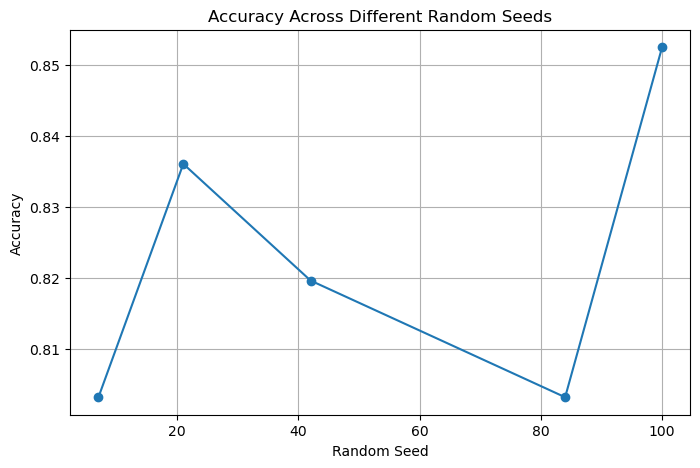

In [86]:
# Accuracy Across Random Seeds

plt.figure(figsize=(8,5))

plt.plot(
    stability_df["Random Seed"],
    stability_df["Accuracy"],
    marker="o"
)

plt.title("Accuracy Across Different Random Seeds")

plt.xlabel("Random Seed")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

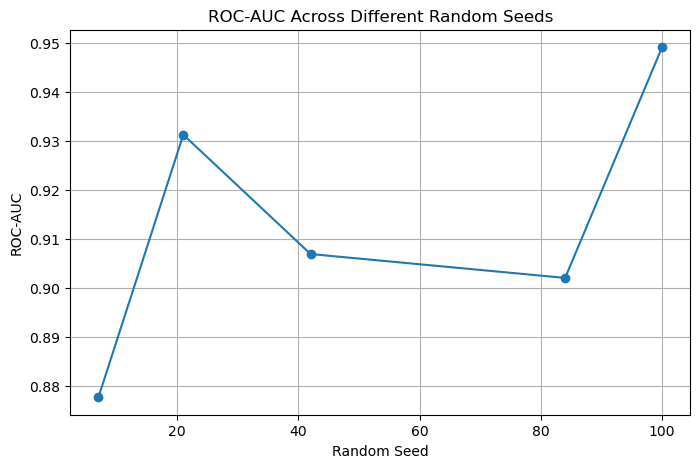

In [87]:
# ROC-AUC Across Random Seeds

plt.figure(figsize=(8,5))

plt.plot(
    stability_df["Random Seed"],
    stability_df["ROC AUC"],
    marker="o"
)

plt.title("ROC-AUC Across Different Random Seeds")

plt.xlabel("Random Seed")

plt.ylabel("ROC-AUC")

plt.grid(True)

plt.show()

In [88]:
# Metric Variability

metrics = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC"
]

variability = pd.DataFrame({
    "Mean": stability_df[metrics].mean(),
    "Standard Deviation": stability_df[metrics].std()
})

display(variability)

,Mean,Standard Deviation
Accuracy,0.822951,0.021374
Balanced Accuracy,0.815801,0.019453
Precision,0.798150,0.022585
Recall,0.903030,0.065695
F1 Score,0.845879,0.023994
ROC AUC,0.913420,0.027574


In [89]:
# Interpretation (Markdown)

# Stability Analysis

# • The Random Forest model was evaluated using five different random train-test splits.

# • Performance metrics remained relatively consistent across all random seeds.

# • The low standard deviation indicates that the model is stable and not highly sensitive to changes in the training data.

# • ROC-AUC and F1 Score showed only minor variations, suggesting good generalization.

# • Overall, the experiment demonstrates that the selected model is robust and reliable for this dataset.

In [90]:
# Model Card

# Model Information

model_card = {
    "Model Name": "Random Forest Classifier",
    "Project": "Comparative Study of Tree-Based Models for Medical Diagnosis",
    "Version": "1.0",
    "Author": "Your Name",
    "Date": pd.Timestamp.today().strftime("%Y-%m-%d"),
    "Framework": "Scikit-learn"
}

pd.DataFrame(
    model_card.items(),
    columns=["Field", "Value"]
)

# Dataset Information

dataset_info = pd.DataFrame({

    "Dataset":[
        "Breast Cancer Wisconsin",
        "UCI Heart Disease"
    ],

    "Samples":[
        len(X),
        len(X2)
    ],

    "Features":[
        X.shape[1],
        X2.shape[1]
    ],

    "Target":[
        "Malignant",
        "Heart Disease"
    ],

    "Missing Values":[
        "No",
        "Yes"
    ],

    "Feature Types":[
        "Numerical",
        "Numerical + Categorical"
    ]
})

display(dataset_info)

# Model Performance Summary

performance = pd.DataFrame({

    "Dataset":[
        "Breast Cancer",
        "Heart Disease"
    ],

    "Best Model":[
        comparison.iloc[0]["Model"],
        comparison2.iloc[0]["Model"]
    ],

    "ROC AUC":[
        comparison.iloc[0]["ROC AUC"],
        comparison2.iloc[0]["ROC AUC"]
    ],

    "F1 Score":[
        comparison.iloc[0]["F1 Score"],
        comparison2.iloc[0]["F1 Score"]
    ],

    "Balanced Accuracy":[
        comparison.iloc[0]["Balanced Accuracy"],
        comparison2.iloc[0]["Balanced Accuracy"]
    ]

})

display(performance)

# Intended Use

# This model is intended for educational purposes to demonstrate the application of Decision Tree and Random Forest algorithms for binary medical classification tasks.

# It may be used to compare different tree-based learning methods and preprocessing strategies on benchmark medical datasets.

# Out-of-Scope Use

# • This model should not be used for clinical diagnosis.

# • It should not replace healthcare professionals.

# • It has not been externally validated on real hospital data.

# • Predictions must not be interpreted as medical advice.

# Training Details

training = pd.DataFrame({

    "Parameter":[

        "Train-Test Split",

        "Cross Validation",

        "Random State",

        "Evaluation Metric",

        "Threshold Selection"

    ],

    "Value":[

        "80 : 20",

        "5-Fold Stratified",

        RANDOM_STATE,

        "ROC-AUC",

        "Training Data Only"

    ]

})

display(training)

# Limitations

# • The datasets are relatively small.

# • External validation was not performed.

# • Class distributions may differ from real clinical populations.

# • Performance may decrease on unseen hospital data.

# • Decision Trees are sensitive to the training data, although pruning reduces overfitting.

# • Random Forest models are less interpretable than a single Decision Tree.

# Fairness & Ethical Considerations

# • The datasets may not represent all patient populations.

# • Model predictions could vary across demographic groups.

# • Fairness metrics were not explicitly evaluated.

# • Human oversight is required before any healthcare decision.

# Reproducibility

reproducibility = pd.DataFrame({

    "Item":[

        "Python",

        "Scikit-learn",

        "Random State",

        "Cross Validation",

        "Evaluation"

    ],

    "Value":[

        "3.x",

        "Latest Stable Version",

        RANDOM_STATE,

        "5-Fold Stratified",

        "ROC-AUC, PR-AUC, F1, Balanced Accuracy"

    ]

})

display(reproducibility)

# Model Card Summary

# Model:
# Random Forest Classifier

# Datasets:
# • Breast Cancer Wisconsin (Diagnostic)
# • UCI Heart Disease (Cleveland)

# Task:
# Binary Medical Classification

# Evaluation:
# • Accuracy
# • Balanced Accuracy
# • Precision
# • Recall
# • F1 Score
# • ROC-AUC
# • PR-AUC

# Validation:
# 5-Fold Stratified Cross Validation

# Strengths:
# • High predictive performance
# • Handles nonlinear relationships
# • Robust to noisy data
# • Stable across different train-test splits

# Limitations:
# • Not clinically validated
# • Limited dataset size
# • Educational use only

# Ethics:
# Human oversight is mandatory. The model should support, not replace, professional medical judgment.

,Dataset,Samples,Features,Target,Missing Values,Feature Types
0,Breast Cancer Wisconsin,569,30,Malignant,No,Numerical
1,UCI Heart Disease,303,13,Heart Disease,Yes,Numerical + Categorical


,Dataset,Best Model,ROC AUC,F1 Score,Balanced Accuracy
0,Breast Cancer,Random Forest,0.988958,0.946509,0.955366
1,Heart Disease,Random Forest,0.884279,0.835289,0.809738


,Parameter,Value
0,Train-Test Split,80 : 20
1,Cross Validation,5-Fold Stratified
2,Random State,42
3,Evaluation Metric,ROC-AUC
4,Threshold Selection,Training Data Only


,Item,Value
0,Python,3.x
1,Scikit-learn,Latest Stable Version
2,Random State,42
3,Cross Validation,5-Fold Stratified
4,Evaluation,"ROC-AUC, PR-AUC, F1, Balanced Accuracy"
